# D2: Data Ingestion & Processing Pipeline - Data Acquisition, Analysis, Wrangling, Feature Engineering 

## Author: Yousef Hussein




## <span style="color:#0B6E4F;">D2.1: Data Acquisition</span>


### Data Acquisition Summary

This notebook contains a multimodal dataset for NVIDIA (NVDA) to predict whether Polymarket odds move **UP** or **DOWN** over the next 24 hours.

Data is collected on a trading-day basis, with timestamps normalized to US Eastern Time. News text, market context features, and Polymarket odds history are also used as a source of data.



### Data Sources

#### **Source 1: Finviz news**
Finviz provides timely headlines that feed the sentiment pipeline. For historical coverage, archived Finviz snapshots are discovered through the Wayback CDX API and then parsed for news headline records.
- Access method: query the Wayback CDX API for historical Finviz snapshot URLs, then scrape archived pages.
- Fields: headline, source, timestamp, URL.
- Output: raw headlines saved as dated files under data/raw.
(check [github repo](https://github.com/ymh1874/FinViz-WebScraper))

#### **Source 2: Yahoo Finance daily prices**
Yahoo Finance provides daily OHLCV and pre-market context features used as explanatory market signals.
- Library: yfinance with daily frequency for NVDA.
- Fields: open, high, low, close, adj close, and volume (plus custom pre-market features in extractor output).
- Missing days: non-trading days are skipped, missing data is imputed, and gaps are logged.
- Output: raw OHLCV and context features saved under data/raw.
(check scripts/yahoo_extractor.py)
#### **Source 3: Polymarket odds history**
Polymarket provides the target signal used for 24-hour UP/DOWN labeling.
- Access method: fetch historical odds time series for the NVDA-relevant contract in the target market.
- Fields: timestamp, contract/asset identifier, and implied probability/odds.
- Label use: compute directional movement over a fixed 24-hour horizon.


In [ ]:
# The commands below document data collection and conversion for D2.1.


# Get historical Finviz snapshots from Wayback CDX API then parse the page (in repo root)
# python scraper.py --ticker NVDA --start 2024-01-01 --end 2026-04-12 --output data/raw/finviz_2426.json

# Download daily OHLCV and intraday features from Yahoo Finance
# python scripts/yahoo_extractor.py --ticker NVDA --start 2024-01-01 --end 2026-04-13 --format json

# Fetch one day of Polymarket daily open/close prices for a matched event query
# python scripts/polymarket_extractor.py "NVIDIA (NVDA) Up or Down on April 16" --start 2026-04-16 --end 2026-04-16 --yes --csv data/processed/polymarket_daily_open_close.csv

# Convert Finviz JSON to CSV
# python scripts/data_converter.py --input data/raw/finviz_2426.json --to csv --output data/processed/finviz_headlines.csv

# Convert stock JSON to CSV
# python scripts/data_converter.py --input data/raw/NVDA_prices_features_2024-01-01_to_2026-04-13.json --to csv --output data/processed/nvda_stock_features.csv

### D2.1.1: Polymarket Extractor (Daily + Intraday Labels)

`scripts/polymarket_extractor.py`  supports full-range backfill for both daily and intraday modeling artifacts.

- **single mode:** one event query for a specific day (manual check).
- **backfill mode:** scans all trading days in a date range and writes consolidated outputs.

This run is configured to match stock coverage (`2024-01-02` to `2026-04-10`) and produce:

- `polymarket_daily_open_close_backfill.csv` (daily open/close labels)
- `polymarket_intraday_mispricing_backfill.csv` (intraday rows with 60-minute forward-return labels)
- `polymarket_backfill_missing_dates.csv` (audit trail for dates with no matching Polymarket market)

For mispricing framing, the intraday file includes `future_return_h60m` and `target_up_move_h60m`, so the model can learn whether current odds are likely under- or over-valued over the next hour.

In [ ]:
#!python ../scripts/polymarket_extractor.py --mode backfill --asset-prefix "NVIDIA (NVDA) Up or Down on" --ticker-symbol NVDA --start 2024-01-02 --end 2026-04-10 --yes --quiet --slug-only --export-intraday --horizon-minutes 60 --csv ../data/processed/polymarket_daily_open_close_backfill.csv --intraday-csv ../data/processed/polymarket_intraday_mispricing_backfill.csv --missing-dates-csv ../data/processed/polymarket_backfill_missing_dates.csv

Saved CSV: ../data/processed/polymarket_daily_open_close_backfill.csv
Saved intraday CSV: ../data/processed/polymarket_intraday_mispricing_backfill.csv
Intraday rows: 683
Saved missing-dates CSV: ../data/processed/polymarket_backfill_missing_dates.csv
Collected rows: 120
Missing dates: 474


## <span style="color:#1D4ED8;">D2.2: Data Analysis</span>

### Analysis Plan

- Data ingestion for stock prices, Finviz news, and Polymarket daily and intraday files.
- EDA for all three sources so structure, quality, and overlap are visible.
- Histogram visualization to inspect distributions and skew behavior.
- Confusion matrix and outlier analysis for quick baseline diagnostics.


In [ ]:
# Step 1: Data ingestion for stock, news, and Polymarket data
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Configure project folders with a robust fallback for different notebook working directories.
project_root = Path("..")
if not (project_root / "data").exists():
    project_root = Path(".")
if not (project_root / "data").exists():
    raise FileNotFoundError("Could not locate the data directory. Run this notebook from the repo root or notebooks folder.")
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# Exact input files for this project
stock_json_path = raw_dir / "NVDA_prices_features_2024-01-01_to_2026-04-13.json"
news_json_path = raw_dir / "finviz_2426.json"
poly_daily_path = processed_dir / "polymarket_master_dataset_h60m.csv"
poly_intraday_path = poly_daily_path

# Load stock and news data from files
with open(stock_json_path, "r", encoding="utf-8") as f:
    stock_records = json.load(f)

with open(news_json_path, "r", encoding="utf-8") as f:
    news_records = json.load(f)

stock_df = pd.DataFrame(stock_records)
news_df = pd.DataFrame(news_records)

if not poly_daily_path.exists():
    raise FileNotFoundError(
        f"Missing Polymarket master file: {poly_daily_path}."
    )

poly_daily_df = pd.read_csv(poly_daily_path)
poly_intraday_df = poly_daily_df.copy()

# Create shared trading-date keys for analysis
stock_df["trade_date"] = pd.to_datetime(stock_df["datetime"], errors="coerce").dt.date
news_df["trade_date"] = pd.to_datetime(news_df["datetime"], errors="coerce").dt.date
if "date" in poly_daily_df.columns:
    poly_daily_df["trade_date"] = pd.to_datetime(poly_daily_df["date"], errors="coerce").dt.date
elif "trade_date" in poly_daily_df.columns:
    poly_daily_df["trade_date"] = pd.to_datetime(poly_daily_df["trade_date"], errors="coerce").dt.date
elif "timestamp_et" in poly_daily_df.columns:
    poly_daily_df["trade_date"] = pd.to_datetime(poly_daily_df["timestamp_et"], errors="coerce").dt.date
else:
    poly_daily_df["trade_date"] = pd.NaT

# Ensure open_price/close_price/pm_return exist for EDA even when source is intraday schema.
for col in ["up_price", "open_price", "close_price", "pm_return", "pm_direction_up"]:
    if col in poly_daily_df.columns:
        poly_daily_df[col] = pd.to_numeric(poly_daily_df[col], errors="coerce")
if not {"open_price", "close_price"}.issubset(poly_daily_df.columns) and {"up_price", "trade_date"}.issubset(poly_daily_df.columns):
    poly_tmp = poly_daily_df.copy()
    if "timestamp_et" in poly_tmp.columns:
        poly_tmp["timestamp_et"] = pd.to_datetime(poly_tmp["timestamp_et"], errors="coerce")
        poly_tmp = poly_tmp.sort_values(["trade_date", "timestamp_et"])
    daily_ohlc = poly_tmp.groupby("trade_date", as_index=False).agg(
        open_price=("up_price", "first"),
        close_price=("up_price", "last"),
    )
    poly_daily_df = poly_daily_df.merge(daily_ohlc, on="trade_date", how="left")
if "pm_return" not in poly_daily_df.columns and {"open_price", "close_price"}.issubset(poly_daily_df.columns):
    poly_daily_df["pm_return"] = (
        (poly_daily_df["close_price"] - poly_daily_df["open_price"])
        / poly_daily_df["open_price"].replace(0, np.nan)
    )
if "pm_direction_up" not in poly_daily_df.columns and {"open_price", "close_price"}.issubset(poly_daily_df.columns):
    poly_daily_df["pm_direction_up"] = np.where(
        poly_daily_df[["open_price", "close_price"]].notna().all(axis=1),
        (poly_daily_df["close_price"] > poly_daily_df["open_price"]).astype(int),
        np.nan,
    )

if "trade_date" in poly_intraday_df.columns:
    poly_intraday_df["trade_date"] = pd.to_datetime(poly_intraday_df["trade_date"], errors="coerce").dt.date
else:
    poly_intraday_df["trade_date"] = pd.to_datetime(poly_intraday_df.get("timestamp_et"), errors="coerce").dt.date

# Use stock table as default EDA numeric frame for legacy steps
df = stock_df.copy()
numeric_cols = df.select_dtypes(include="number").columns.tolist()
#remove duplicate date columns if they exist
stock_dates = set(stock_df["trade_date"].dropna())
poly_dates = set(poly_daily_df["trade_date"].dropna())
date_overlap = len(stock_dates & poly_dates)

print(f"Stock rows: {len(stock_df)}, columns: {stock_df.shape[1]}")
print(f"News rows: {len(news_df)}, columns: {news_df.shape[1]}")
print(f"Polymarket source used: {poly_daily_path.name}")
print(f"Polymarket daily rows: {len(poly_daily_df)}, columns: {poly_daily_df.shape[1]}")
print(f"Polymarket intraday rows: {len(poly_intraday_df)}, columns: {poly_intraday_df.shape[1]}")
print(f"Stock/Polymarket overlap dates: {date_overlap}")
print(f"Numeric columns in stock table: {len(numeric_cols)}")

Stock rows: 570, columns: 10
News rows: 45775, columns: 4
Polymarket source used: polymarket_master_dataset_h60m.csv
Polymarket daily rows: 503, columns: 40
Polymarket intraday rows: 503, columns: 38
Stock/Polymarket overlap dates: 118
Numeric columns in stock table: 8


### <span style="color:#0F766E;">Findings: Step 1 Data Ingestion</span>

The ingestion check confirms that all three raw domains are available in memory: stock context, Finviz headlines, and Polymarket odds. This is important because the downstream quality checks and merges rely on a shared `trade_date` key, not independent index order.


### Step 2: EDA for Stock, News, and Polymarket (Pre-Imputation)
This block runs structural EDA for all three datasets. It includes schema checks, missing-value profiles, summary statistics, and visual diagnostics to surface quality issues before cleaning.

=== Stock Dataset EDA ===
Shape: (570, 10)

Columns: ['datetime', 'end_price', 'high', 'low', 'start_price', 'volume', 'pre_market_gap_pct', 'gap_direction_matches_trend', 'pre_market_volume_relative', 'trade_date']

Dtypes:
 datetime                           str
end_price                      float64
high                           float64
low                            float64
start_price                    float64
volume                           int64
pre_market_gap_pct             float64
gap_direction_matches_trend      int64
pre_market_volume_relative     float64
trade_date                      object
dtype: object

First 5 rows:


,datetime,end_price,high,low,start_price,volume,pre_market_gap_pct,gap_direction_matches_trend,pre_market_volume_relative,trade_date
0,2024-01-02T00:00:00,48.138569,49.264879,47.565921,49.213912,411254000,NaN,1,1.0,2024-01-02
1,2024-01-03T00:00:00,47.539936,48.154558,47.291088,47.455988,320896000,-0.014180,1,1.0,2024-01-03
2,2024-01-04T00:00:00,47.968678,48.470370,47.478975,47.737816,306535000,0.004162,0,1.0,2024-01-04
3,2024-01-05T00:00:00,49.067005,49.516731,48.276488,48.432395,415039000,0.009667,0,1.0,2024-01-05
4,2024-01-08T00:00:00,52.221085,52.243074,49.448781,49.481761,642510000,0.008453,0,1.0,2024-01-08



Missing values (stock):


,missing_count,missing_pct
pre_market_gap_pct,1,0.1800



Summary statistics (stock):


,mean,median,variance,skew
end_price,136.9861,135.0620,"1,470.7392",-0.2044
high,139.2366,137.3116,"1,496.0672",-0.2167
low,134.5695,132.6087,"1,457.2856",-0.1850
start_price,137.0592,135.8200,"1,483.6833",-0.2028
volume,"284,701,492.28","231,372,050","22,586,589,533,056,916",1.5503
pre_market_gap_pct,0.0027,0.0028,0.0004,-0.8463
gap_direction_matches_trend,0.5404,1,0.2488,-0.1624
pre_market_volume_relative,1,1,0,0


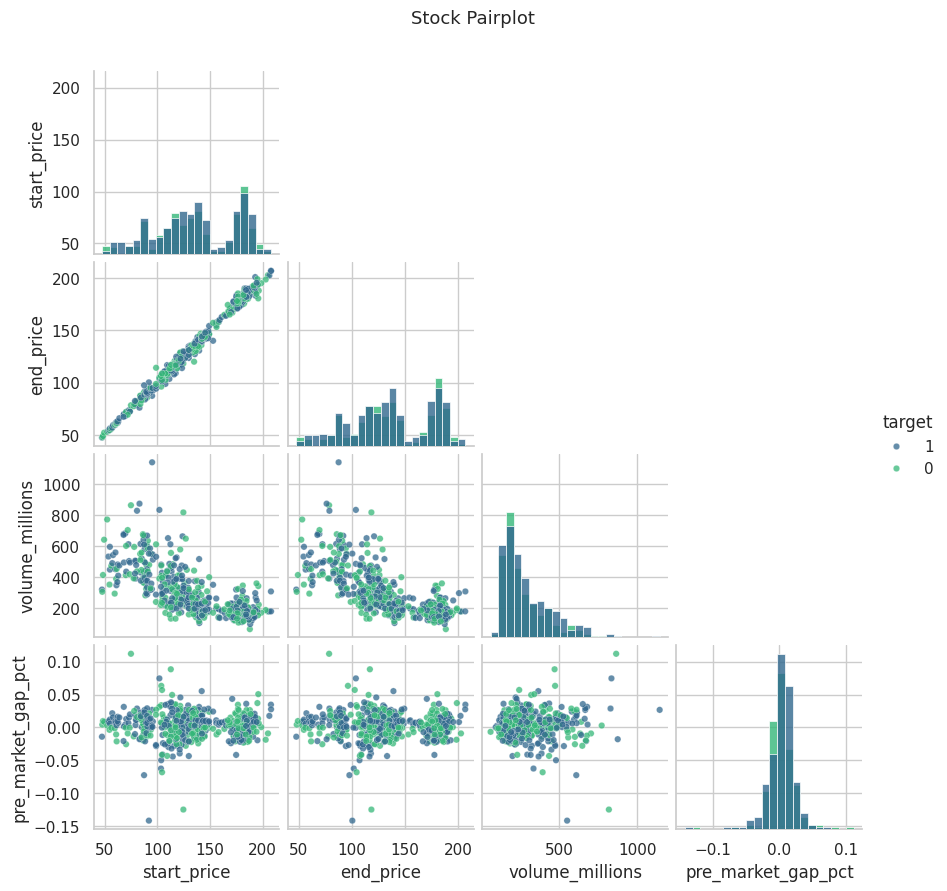

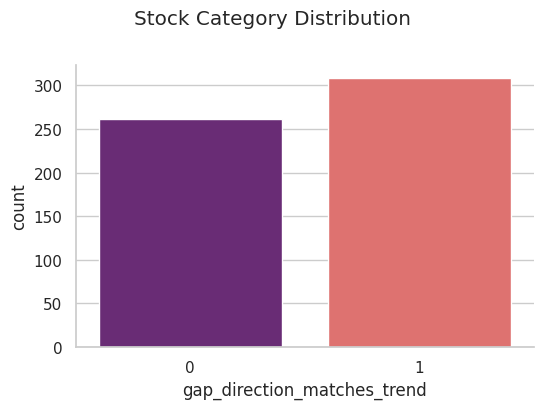


=== Finviz News Dataset EDA ===
Shape: (45775, 4)

Columns: ['datetime', 'headline', 'source', 'trade_date']

Dtypes:
 datetime         str
headline         str
source           str
trade_date    object
dtype: object

First 5 rows:


,datetime,headline,source,trade_date
0,2024-01-01T07:00:00,The Tax Whiz With the Strangest Hustle on Wall...,WSJ,2024-01-01
1,2024-01-01T06:06:00,"Earthquake slams Japan, residents flee some co...",Reuters,2024-01-01
2,2024-01-01T06:02:00,Stock market highs complicate Trump's 2024 mes...,Yahoo,2024-01-01
3,2024-01-01T05:30:00,Optimism Abounds on Wall Street This New Year,WSJ,2024-01-01
4,2024-01-01T05:00:00,Chill in the Housing Market Seeps Into Other I...,THE NY Times,2024-01-01



Missing values (news):
  None found.

Summary statistics (news):


,mean,median,variance,skew
headline_length,63.2930,63,259.9360,0.3663
hour_of_day,10.6218,11,15.5220,-0.1285
headline_word_count,10.3400,10,7.7666,0.5000


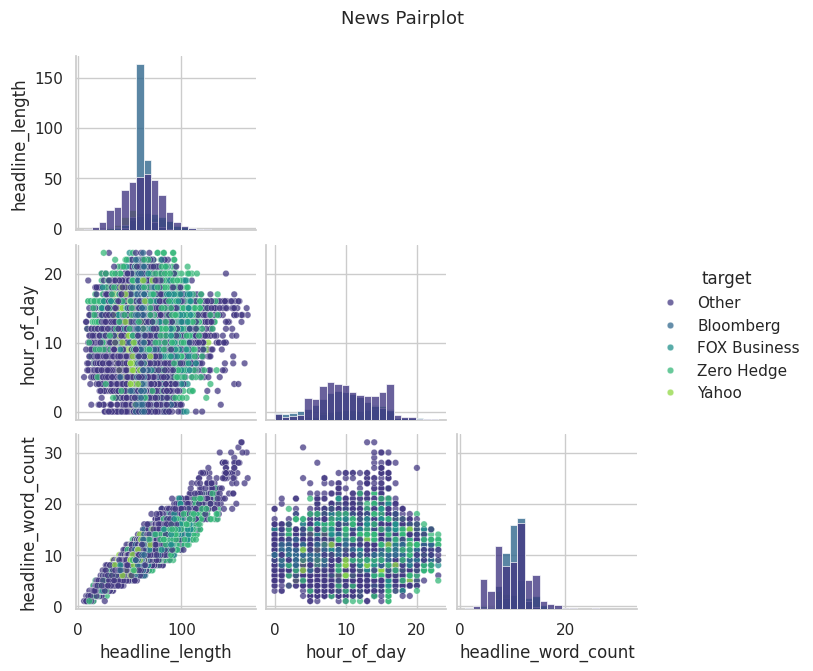

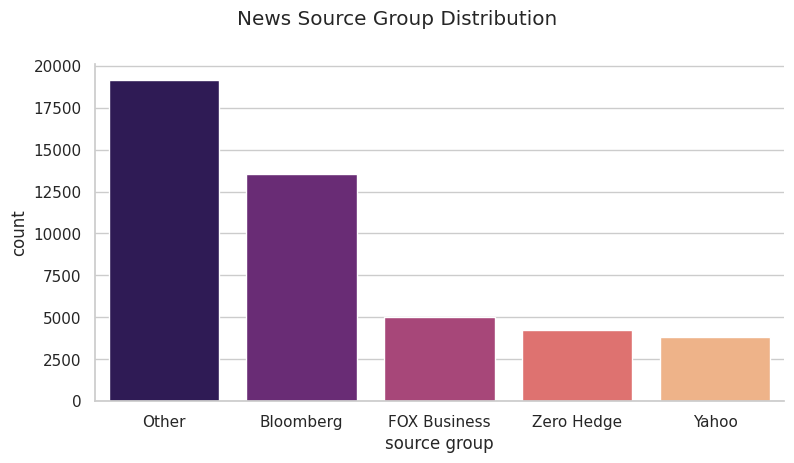


=== Polymarket Daily Dataset EDA ===
Shape: (503, 40)

Columns: ['trade_date', 'timestamp_et', 'up_price', 'down_price', 'minute_from_open', 'minute_sin', 'minute_cos', 'up_ret_1', 'up_ret_3', 'up_sma_5', 'up_std_5', 'up_vs_sma_5', 'pre_market_gap_pct', 'pre_market_volume_relative', 'gap_direction_matches_trend', 'stock_return_1d', 'high_low_range_pct', 'volume_vs_5d', 'future_return_h60m', 'target_up_move_h60m', 'is_underpriced_up_h60m', 'is_overpriced_up_h60m', 'realized_edge_h60m', 'event_query', 'matched_event', 'start_price', 'end_price', 'high', 'low', 'volume', 'stock_return_lag1', 'stock_return_lag2', 'ret_mean_5d', 'ret_std_5d', 'log_volume', 'close_pos_in_range', 'pm_direction_up', 'pm_return', 'open_price', 'close_price']

Dtypes:
 trade_date                      object
timestamp_et                       str
up_price                       float64
down_price                     float64
minute_from_open                 int64
minute_sin                     float64
minute_cos  

,trade_date,timestamp_et,up_price,down_price,minute_from_open,minute_sin,minute_cos,up_ret_1,up_ret_3,up_sma_5,...,stock_return_lag1,stock_return_lag2,ret_mean_5d,ret_std_5d,log_volume,close_pos_in_range,pm_direction_up,pm_return,open_price,close_price
0,2025-10-15,2025-10-15 10:00:04,0.405,0.595,30,0.464723,0.885456,0.000000,0.00000,0.405000,...,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506,0.405,0.035
1,2025-10-15,2025-10-15 11:00:16,0.270,0.730,90,0.992709,0.120537,-0.333333,0.00000,0.337500,...,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506,0.405,0.035
2,2025-10-15,2025-10-15 12:00:03,0.155,0.845,150,0.663123,-0.748511,-0.425926,0.00000,0.276667,...,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506,0.405,0.035
3,2025-10-15,2025-10-15 13:00:20,0.035,0.965,210,-0.239316,-0.970942,-0.774194,-0.91358,0.216250,...,-0.025654,0.001862,-0.020480,0.023192,19.183590,0.335093,0,-0.939506,0.405,0.035
4,2025-10-16,2025-10-16 10:00:16,0.720,0.280,30,0.464723,0.885456,0.000000,0.00000,0.720000,...,-0.026894,-0.025654,-0.021295,0.022268,19.006929,0.581196,1,0.048611,0.720,0.785



Missing values (polymarket_daily):
  None found.

Summary statistics (polymarket_daily):


,mean,median,variance,skew
up_price,0.5327,0.5600,0.1242,-0.1351
down_price,0.4673,0.4400,0.1242,0.1351
open_price,0.5331,0.5100,0.0923,-0.0910
close_price,0.5324,0.6200,0.1478,-0.1454
pm_return,-0.1363,-0.0219,0.6509,2.5225
future_return_h60m,0.0262,0,2.4736,16.8701


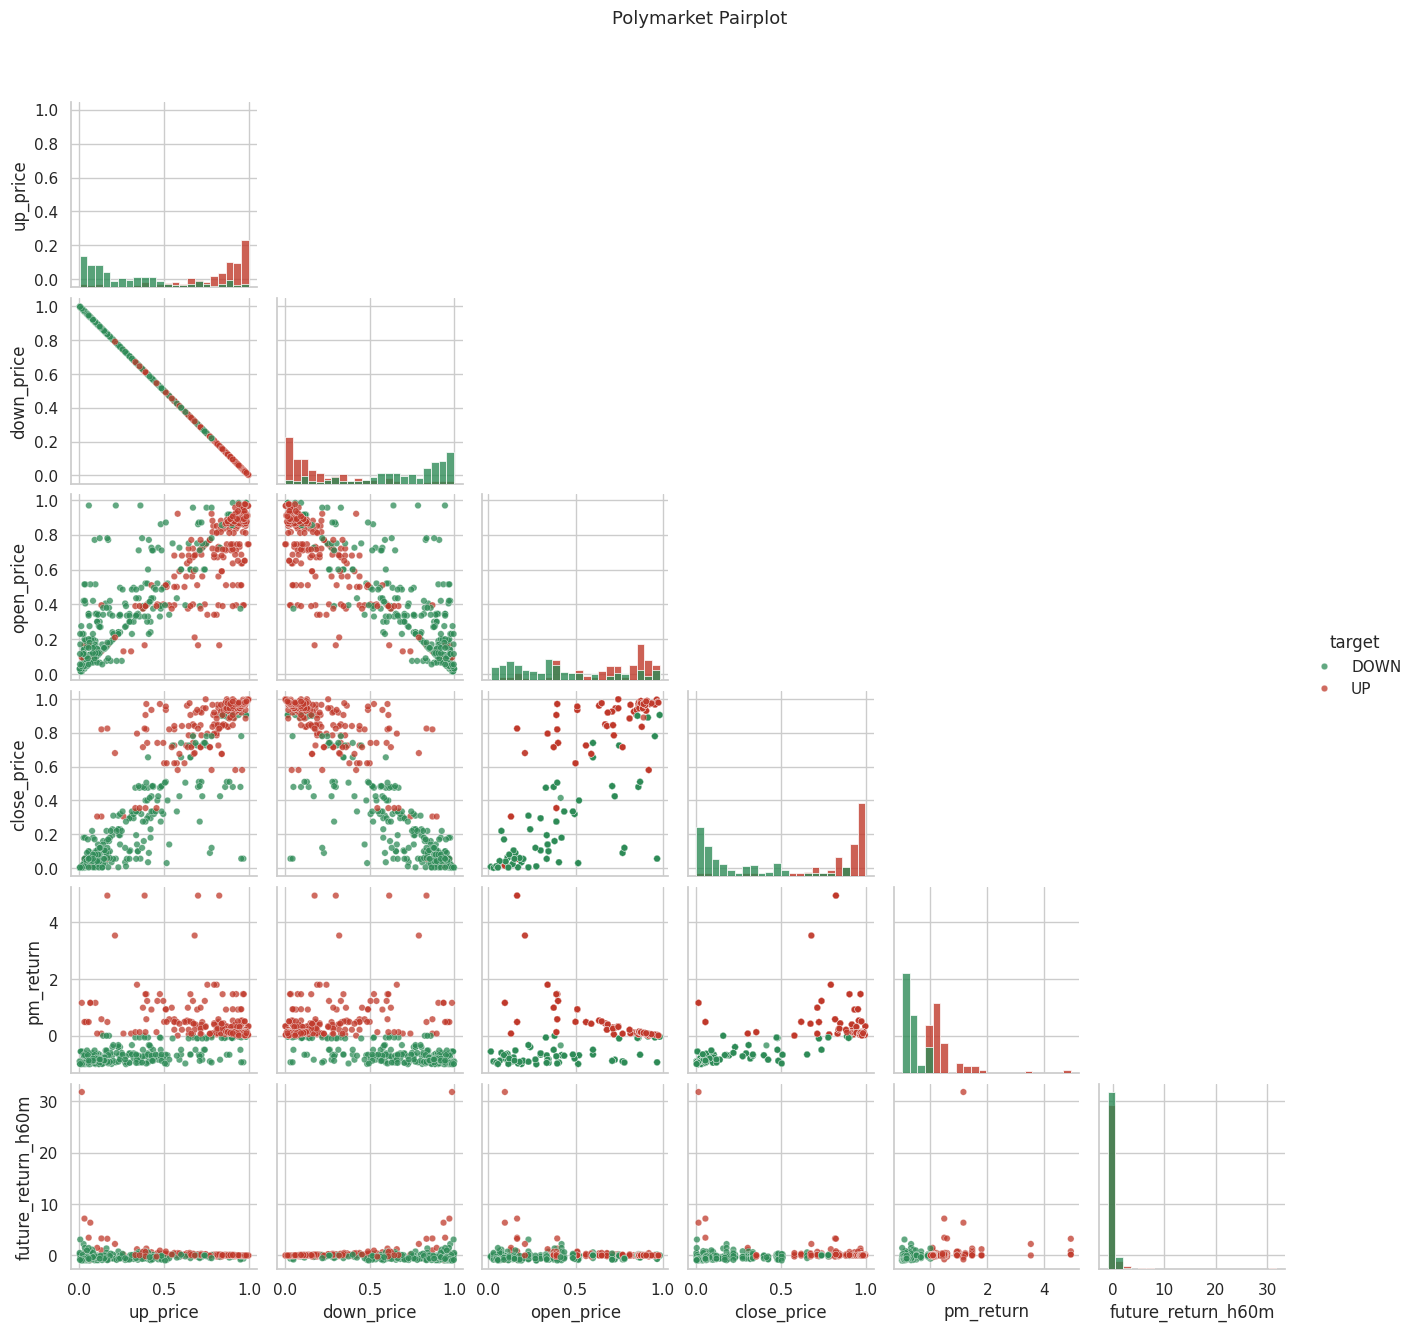

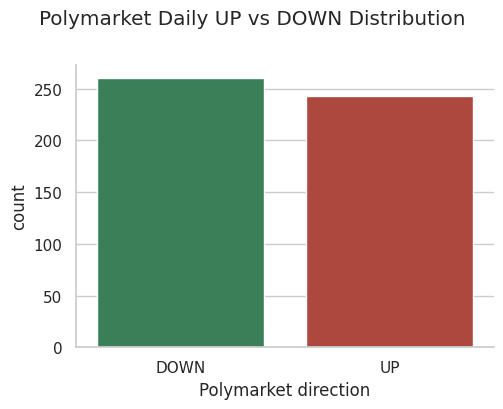

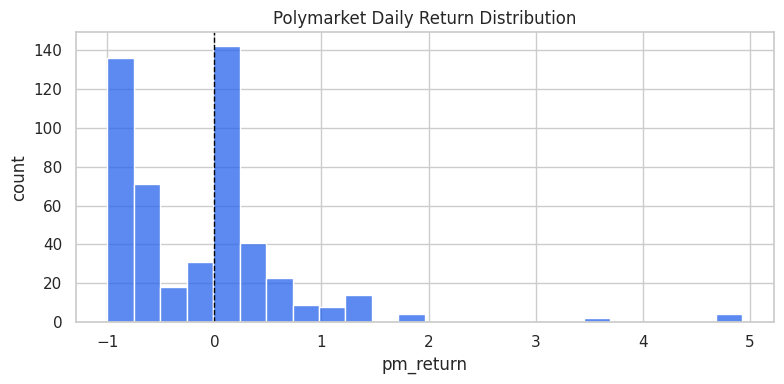

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

#plot style
sns.set_theme(style="whitegrid", context="notebook")
#visualization settings
PALETTE = "viridis"
PLOT_KWS = {"s": 22, "alpha": 0.75, "edgecolor": "white", "linewidth": 0.25}
DIAG_KWS = {"bins": 22, "alpha": 0.8}

# formatting helper for display
def fmt(x):
    if pd.isna(x):
        return "NaN"
    x = float(x)
    if x.is_integer():
        return f"{int(x):,}"
    
    # For large numbers, use 2 decimal places; for smaller numbers, use 4 decimal places
    if abs(x) >= 1_000_000:
        return f"{x:,.2f}"
    return f"{x:,.4f}"


def display_clean(frame):
    display(frame.copy().map(fmt))

# Missing value report function for any dataframe with count and percentage, 
# sorted by count descending, and only showing columns with missing values. Labeled by dataset name for clarity.
def missing_report(frame, label):
    counts = frame.isna().sum()
    pct = (counts / len(frame) * 100).round(2)
    report = pd.DataFrame({"missing_count": counts, "missing_pct": pct})
    report = report[report["missing_count"] > 0].sort_values("missing_count", ascending=False)
    print(f"\nMissing values ({label}):")
    if report.empty:
        print("  None found.")
    else:
        display_clean(report)

# Summary statistics function for numeric columns of a dataframe, showing mean, median, variance, and skewness. 
# Labeled by dataset name for clarity.
def summary_stats(frame, cols, label):
    if not cols:
        print(f"\nSummary statistics ({label}): skipped (no numeric columns).")
        return
    stats = pd.DataFrame({
        "mean": frame[cols].mean(),
        "median": frame[cols].median(),
        "variance": frame[cols].var(),
        "skew": frame[cols].skew(),
    }).round(4)
    print(f"\nSummary statistics ({label}):")
    display_clean(stats)

# Helper to hide upper triangle of pairplot for cleaner visualization
# https://stackoverflow.com/questions/34087126/plot-lower-triangle-in-a-seaborn-pairgrid
def hide_upper_triangle(grid):
    for i, j in zip(*np.triu_indices_from(grid.axes, k=1)):
        grid.axes[i, j].set_visible(False)


# Stock EDA 
print("=== Stock Dataset EDA ===")
print("Shape:", stock_df.shape)
print("\nColumns:", stock_df.columns.tolist())
print("\nDtypes:\n", stock_df.dtypes)
print("\nFirst 5 rows:")
display(stock_df.head())

missing_report(stock_df, "stock")
stock_numeric = stock_df.select_dtypes(include="number").columns.tolist()
summary_stats(stock_df, stock_numeric, "stock")

# Create a target variable for visualization based on gap_direction_matches_trend if it exists, otherwise use NaN. 
# Also create a volume in millions column if volume exists for better scaling in plots.
stock_plot = stock_df.copy()
stock_plot["target"] = stock_plot.get("gap_direction_matches_trend", pd.Series(index=stock_plot.index)).astype(str)

# For better visualization, convert volume to millions if it exists, otherwise set to NaN for consistent plotting.
if "volume" in stock_plot.columns:
    stock_plot["volume_millions"] = stock_plot["volume"] / 1_000_000
else:
    stock_plot["volume_millions"] = np.nan

# For pairplot, select of numeric variables that are commonly relevant for stock analysis and exist in the dataset.
stock_vars = [c for c in ["start_price", "end_price", "volume_millions", "pre_market_gap_pct"] if c in stock_plot.columns]
if len(stock_vars) >= 2:
    stock_pair_df = stock_plot[stock_vars + ["target"]].dropna()
    if not stock_pair_df.empty:
        g = sns.pairplot(
            stock_pair_df,
            vars=stock_vars,
            hue="target",
            palette=PALETTE,
            corner=False,
            diag_kind="hist",
            height=2.2,
            plot_kws=PLOT_KWS,
            diag_kws=DIAG_KWS,
        )
        hide_upper_triangle(g)
        g.figure.suptitle("Stock Pairplot", y=1.01, fontsize=13)
        g.figure.subplots_adjust(top=0.94)
        plt.show()
else:
    print("Stock pairplot skipped: not enough numeric variables.")

# For the categorical distribution plot, only proceed if the target variable has valid values (not all NaN) to avoid empty plots.
if "gap_direction_matches_trend" in stock_plot.columns:
    g2 = sns.catplot(
        data=stock_plot,
        x="gap_direction_matches_trend",
        hue="target",
        kind="count",
        palette="magma",
        height=4,
        aspect=1.4,
    )
    g2.set_axis_labels("gap_direction_matches_trend", "count")
    g2.figure.suptitle("Stock Category Distribution", y=1.02)
    g2.figure.subplots_adjust(top=0.88)
    plt.show()


# News EDA
print("\n=== Finviz News Dataset EDA ===")
print("Shape:", news_df.shape)
print("\nColumns:", news_df.columns.tolist())
print("\nDtypes:\n", news_df.dtypes)
print("\nFirst 5 rows:")
display(news_df.head())

missing_report(news_df, "news")

news = news_df.copy()
news_dt = pd.to_datetime(news.get("datetime"), errors="coerce")

# Create headline-based features: length, hour of day, word count. 
# Also create a target variable based on source if it exists, otherwise use "Unknown".
news["headline"] = news.get("headline", pd.Series(index=news.index, dtype="object")).astype(str)
news["headline_length"] = news["headline"].str.len()
news["hour_of_day"] = news_dt.dt.hour
news["headline_word_count"] = news["headline"].str.split().str.len()

news_vars = ["headline_length", "hour_of_day", "headline_word_count"]
summary_stats(news, news_vars, "news")
# For the target variable, if "source" exists, group by top 4 sources and label the rest as "Other".
# If "source" doesn't exist, use "Unknown".
if "source" in news.columns:
    top_sources = news["source"].value_counts().head(4).index.tolist()
    news["target"] = news["source"].where(news["source"].isin(top_sources), "Other")
else:
    news["target"] = "Unknown"
target_order = news["target"].value_counts().index.tolist()
# For pairplot, only use the news_vars and target, and drop rows with missing values. 
news_pair_df = news[news_vars + ["target"]].dropna()
if not news_pair_df.empty:
    g3 = sns.pairplot(
        news_pair_df,
        vars=news_vars,
        hue="target",
        hue_order=target_order,
        palette=PALETTE,
        corner=False,
        diag_kind="hist",
        height=2.2,
        plot_kws=PLOT_KWS,
        diag_kws=DIAG_KWS,
    )
    hide_upper_triangle(g3)
    g3.figure.suptitle("News Pairplot", y=1.01, fontsize=13)
    g3.figure.subplots_adjust(top=0.94)
    plt.show()
# For the categorical distribution plot, only proceed if the target variable has valid values.
g4 = sns.catplot(
    data=news,
    x="target",
    hue="target",
    order=target_order,
    hue_order=target_order,
    kind="count",
    palette="magma",
    height=4.5,
    aspect=1.8,
    legend=False,
    )
g4.set_axis_labels("source group", "count")
g4.figure.suptitle("News Source Group Distribution", y=1.02)
g4.figure.subplots_adjust(top=0.9, bottom=0.15)
plt.show()


# Polymarket Daily EDA
print("\n=== Polymarket Daily Dataset EDA ===")
print("Shape:", poly_daily_df.shape)
print("\nColumns:", poly_daily_df.columns.tolist())
print("\nDtypes:\n", poly_daily_df.dtypes)
print("\nFirst 5 rows:")
display(poly_daily_df.head())

poly_daily = poly_daily_df.copy()
# Support either daily open/close schema or intraday mispricing schema.
if "date" in poly_daily.columns:
    poly_daily["trade_date"] = pd.to_datetime(poly_daily["date"], errors="coerce").dt.date
elif "trade_date" in poly_daily.columns:
    poly_daily["trade_date"] = pd.to_datetime(poly_daily["trade_date"], errors="coerce").dt.date
elif "timestamp_et" in poly_daily.columns:
    poly_daily["trade_date"] = pd.to_datetime(poly_daily["timestamp_et"], errors="coerce").dt.date
else:
    poly_daily["trade_date"] = pd.NaT
for col in ["up_price", "open_price", "close_price", "pm_return", "pm_direction_up", "target_up_move_h60m"]:
    if col in poly_daily.columns:
        poly_daily[col] = pd.to_numeric(poly_daily[col], errors="coerce")
if "pm_return" not in poly_daily.columns and {"open_price", "close_price"}.issubset(poly_daily.columns):
    poly_daily["pm_return"] = (
        (poly_daily["close_price"] - poly_daily["open_price"])
        / poly_daily["open_price"].replace(0, np.nan)
    )
if "pm_direction_up" not in poly_daily.columns:
    if "target_up_move_h60m" in poly_daily.columns:
        poly_daily["pm_direction_up"] = poly_daily["target_up_move_h60m"]
    elif {"open_price", "close_price"}.issubset(poly_daily.columns):
        poly_daily["pm_direction_up"] = np.where(
            poly_daily[["open_price", "close_price"]].notna().all(axis=1),
            (poly_daily["close_price"] > poly_daily["open_price"]).astype(int),
            np.nan,
        )
    else:
        poly_daily["pm_direction_up"] = np.nan
# For the Polymarket daily data, pick a robust set of numeric variables across daily and intraday schemas.
missing_report(poly_daily, "polymarket_daily")
poly_vars = [
    c
    for c in ["up_price", "down_price", "open_price", "close_price", "pm_return", "future_return_h60m"]
    if c in poly_daily.columns
]
if len(poly_vars) < 2:
    numeric_pool = poly_daily.select_dtypes(include="number").columns.tolist()
    excluded = {"pm_direction_up", "target_up_move_h60m"}
    poly_vars = [c for c in numeric_pool if c not in excluded][:3]
summary_stats(poly_daily, poly_vars, "polymarket_daily")

poly_plot = poly_daily.copy()
# Create a target variable for visualization based on pm_direction_up, mapping 1 to "UP" and 0 to "DOWN".
poly_plot["target"] = poly_plot["pm_direction_up"].map({1.0: "UP", 0.0: "DOWN"})

# For pairplot, select the relevant numeric variables and the target, and drop rows with missing values.
if len(poly_vars) >= 2:
    poly_pair_df = poly_plot[poly_vars + ["target"]].dropna()
    if not poly_pair_df.empty:
        g5 = sns.pairplot(
            poly_pair_df,
            vars=poly_vars,
            hue="target",
            palette=["#2E8B57", "#C0392B"],
            corner=False,
            diag_kind="hist",
            height=2.2,
            plot_kws=PLOT_KWS,
            diag_kws=DIAG_KWS,
        )
        hide_upper_triangle(g5)
        g5.figure.suptitle("Polymarket Pairplot", y=1.01, fontsize=13)
        g5.figure.subplots_adjust(top=0.94)
        plt.show()
    else:
        print("Polymarket pairplot skipped: no rows remain after dropping missing values for selected columns.")
else:
    print("Polymarket pairplot skipped: fewer than 2 usable numeric variables.")
# For the categorical distribution plot, only proceed if the target variable has valid values (not all NaN) to avoid empty plots.
poly_count = poly_plot.dropna(subset=["target"])
if not poly_count.empty:
    g6 = sns.catplot(
        data=poly_count,
        x="target",
        hue="target",
        kind="count",
        palette=["#2E8B57", "#C0392B"],
        height=4,
        aspect=1.3,
        legend=False,
    )
    g6.set_axis_labels("Polymarket direction", "count")
    g6.figure.suptitle("Polymarket Daily UP vs DOWN Distribution", y=1.02)
    g6.figure.subplots_adjust(top=0.88)
    plt.show()
# Finally, plot the distribution of pm_return if it exists and has valid values,
#  to understand the return characteristics of the Polymarket daily data.
if "pm_return" in poly_plot.columns and poly_plot["pm_return"].notna().any():
    plt.figure(figsize=(8, 4))
    sns.histplot(poly_plot["pm_return"].dropna(), bins=24, color="#2563EB", edgecolor="white")
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Polymarket Daily Return Distribution")
    plt.xlabel("pm_return")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

### Step 3: Histogram Visualization (Stock, News, Polymarket)
This block visualizes numeric distributions for all three domains so skewness, spread, and potential outliers are visible before selecting imputation strategies in D2.3.

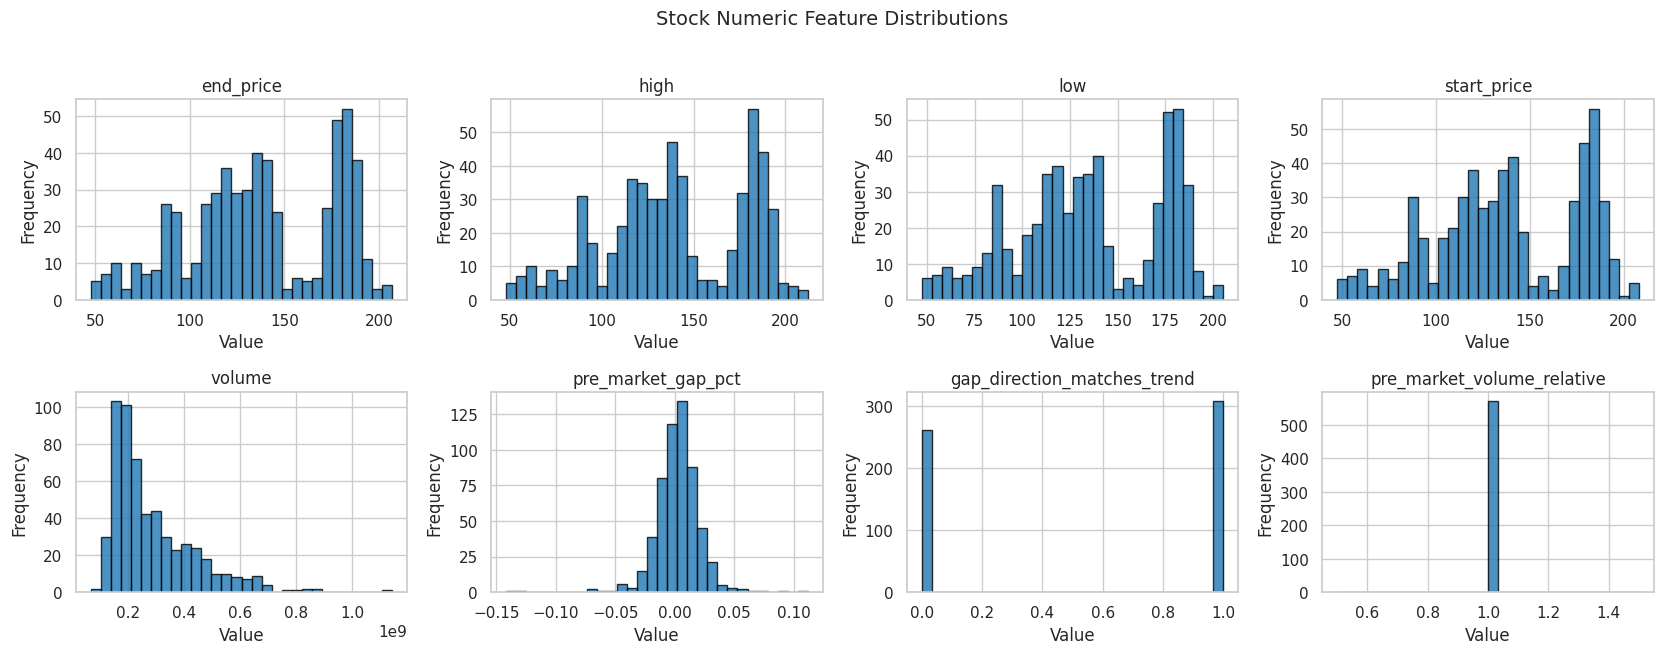

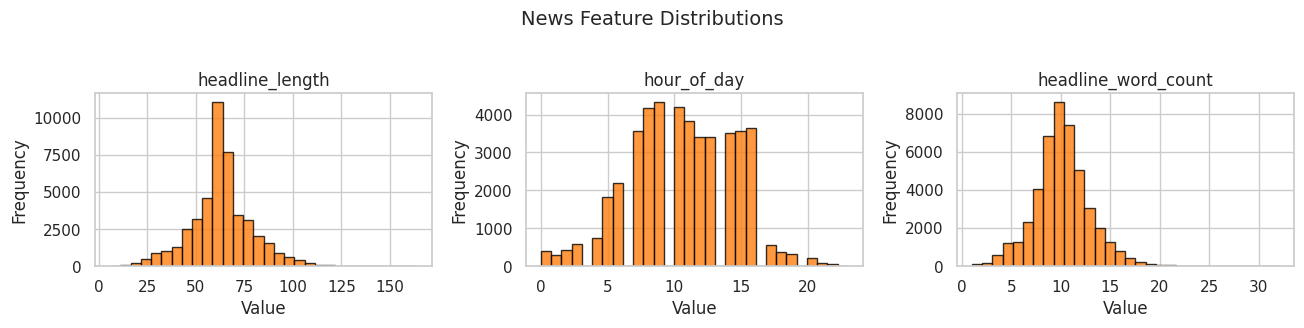

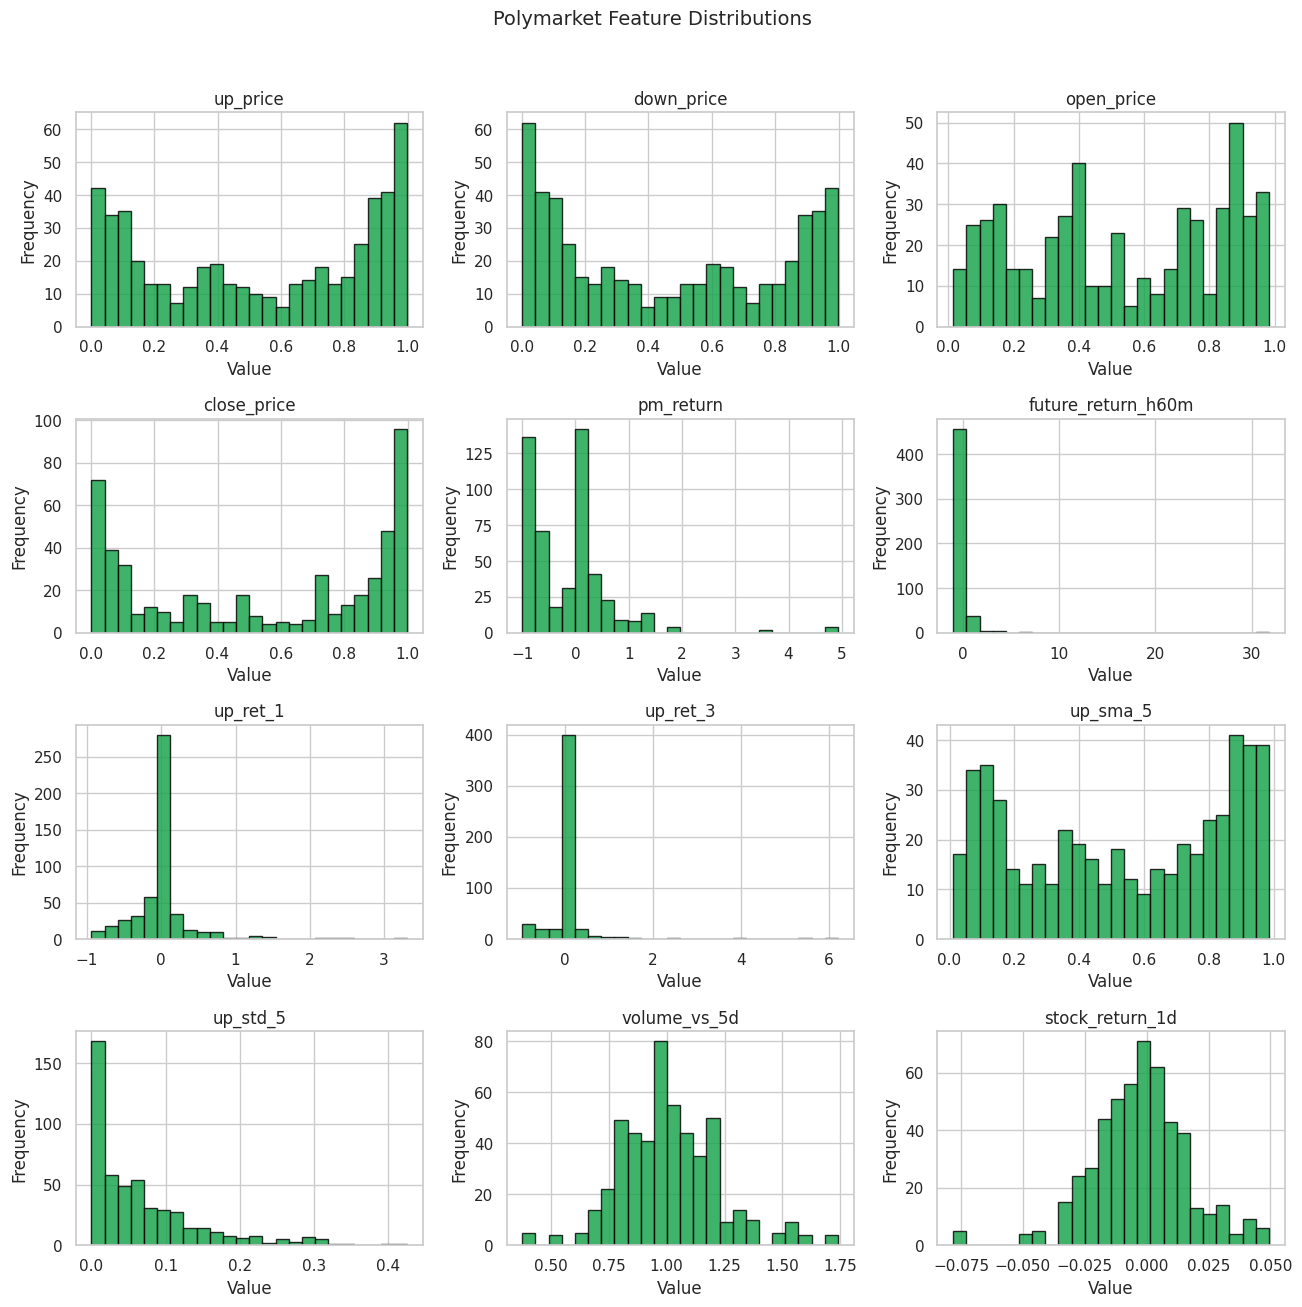

In [4]:
# Step 3: Histogram visualization for stock, news, and Polymarket
import math
import numpy as np

# Stock histograms
stock_numeric_cols = df.select_dtypes(include="number").columns.tolist()

if stock_numeric_cols:
    n_cols = 4
    n_rows = math.ceil(len(stock_numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(stock_numeric_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor="black", color="#1f77b4", alpha=0.8)
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(stock_numeric_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Stock Numeric Feature Distributions", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("No numeric columns available for stock histogram plotting.")

# News histograms - only for headline-based features since other columns are mostly categorical or datetime.
news_hist = news_df.copy()
news_dt = pd.to_datetime(news_hist["datetime"], errors="coerce")
news_hist["headline_length"] = news_hist["headline"].astype(str).str.len()
news_hist["hour_of_day"] = news_dt.dt.hour
news_hist["headline_word_count"] = news_hist["headline"].astype(str).str.split().str.len()

news_numeric_cols = ["headline_length", "hour_of_day", "headline_word_count"]
news_plot_df = news_hist[news_numeric_cols].dropna()

if not news_plot_df.empty:
    n_cols = 3
    n_rows = math.ceil(len(news_numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(news_numeric_cols):
        axes[i].hist(news_plot_df[col], bins=30, edgecolor="black", color="#ff7f0e", alpha=0.8)
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(news_numeric_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("News Feature Distributions", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
else:
    print("No numeric news features available for histogram plotting.")

# Polymarket histograms - include a wider set of available numeric features.
poly_hist = poly_daily_df.copy()

# Convert known candidate feature columns to numeric where present.
poly_candidate_cols = [
    "up_price",
    "down_price",
    "open_price",
    "close_price",
    "pm_return",
    "future_return_h60m",
    "up_ret_1",
    "up_ret_3",
    "up_sma_5",
    "up_std_5",
    "volume_vs_5d",
    "stock_return_1d",
    "pre_market_gap_pct",
]
for col in poly_candidate_cols:
    if col in poly_hist.columns:
        poly_hist[col] = pd.to_numeric(poly_hist[col], errors="coerce")

# Derive daily open/close from intraday up_price if missing.
if not {"open_price", "close_price"}.issubset(poly_hist.columns) and {"up_price", "trade_date"}.issubset(poly_hist.columns):
    poly_tmp = poly_hist.copy()
    if "timestamp_et" in poly_tmp.columns:
        poly_tmp["timestamp_et"] = pd.to_datetime(poly_tmp["timestamp_et"], errors="coerce")
        poly_tmp = poly_tmp.sort_values(["trade_date", "timestamp_et"])
    daily_ohlc = poly_tmp.groupby("trade_date", as_index=False).agg(
        open_price=("up_price", "first"),
        close_price=("up_price", "last"),
    )
    poly_hist = poly_hist.merge(daily_ohlc, on="trade_date", how="left")

# Derive pm_return if missing and open/close exist.
if "pm_return" not in poly_hist.columns and {"open_price", "close_price"}.issubset(poly_hist.columns):
    poly_hist["pm_return"] = (
        (poly_hist["close_price"] - poly_hist["open_price"])
        / poly_hist["open_price"].replace(0, pd.NA)
    )

# Select available candidate columns; if too few, fall back to generic numeric columns.
poly_numeric_cols = [c for c in poly_candidate_cols if c in poly_hist.columns]
if len(poly_numeric_cols) < 2:
    fallback_numeric = poly_hist.select_dtypes(include="number").columns.tolist()
    excluded = {"pm_direction_up", "target_up_move_h60m"}
    poly_numeric_cols = [c for c in fallback_numeric if c not in excluded]

# Keep charts readable by plotting up to 12 features.
poly_numeric_cols = poly_numeric_cols[:12]

if poly_numeric_cols:
    n_cols = min(3, len(poly_numeric_cols))
    n_rows = math.ceil(len(poly_numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.2 * n_rows))
    if not isinstance(axes, (list, tuple, np.ndarray)):
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    # Plot each feature independently so one sparse column does not remove all rows.
    plotted_count = 0
    for i, col in enumerate(poly_numeric_cols):
        series = pd.to_numeric(poly_hist[col], errors="coerce").dropna()
        if series.empty:
            axes[i].set_visible(False)
            continue
        axes[i].hist(series, bins=24, edgecolor="black", color="#16a34a", alpha=0.82)
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")
        plotted_count += 1

    for j in range(len(poly_numeric_cols), len(axes)):
        axes[j].set_visible(False)

    if plotted_count > 0:
        fig.suptitle("Polymarket Feature Distributions", y=1.02, fontsize=14)
        fig.tight_layout()
        plt.show()
    else:
        print("Polymarket histogram skipped: selected columns contain no numeric values after cleaning.")
else:
    print("No numeric Polymarket features available for histogram plotting.")

# Exploratory Data Analysis (EDA)


This report analyzes three datasets: **Stock Data**, **Finviz News Data**, and **Polymarket Daily Data**.

---

# Stock Dataset EDA

## 1. Distribution and Structure

The dataset contains **570 rows and 10 columns**, mostly numeric features related to price and trading activity.

### Key observations
- Prices (`start_price`, `end_price`, `high`, `low`) are tightly clustered around ~135
- Variance is moderate across all price features (~1400 range)
- `volume` has extremely high variance and strong right skew
- `pre_market_gap_pct` is centered near 0 with small spread

### Important insights
- Slight **negative skew** in price variables suggests a mild tail toward lower values
- `volume` has **strong positive skew (1.55)** indicating occasional spikes

---

## 2. Correlation and Relationships

From the pairplot:

### Strong correlations
- `start_price` vs `end_price`
  - Almost perfectly linear relationship
  - Suggests minimal intraday volatility relative to price level
- `high`, `low`, `start_price`, `end_price`
  - All highly correlated
  - These features are likely redundant for modeling

### Weak or no correlation
- `volume_millions` vs price features
  - No clear linear relationship
  - Volume does not directly explain price level
- `pre_market_gap_pct` vs all variables
  - Scattered distribution
  - Weak predictive signal on its own

---

## 3. Target Behavior and Signal Quality

Target: `gap_direction_matches_trend` (0 or 1)

### Observations
- Slight imbalance toward class `1` (~54%)
- No strong separation between classes in pairplots
- Significant overlap across all feature combinations

### Implications
- The dataset is **not linearly separable**
- Likely requires:
  - Feature engineering
  - Nonlinear models

---

# Finviz News Dataset EDA

## 1. Text Feature Distributions

Dataset size is significantly larger with **45,775 rows**.

### Engineered features
- `headline_length`
- `headline_word_count`
- `hour_of_day`

### Observations
- Headlines cluster around:
  - 50 to 100 characters
  - 8 to 15 words
- `hour_of_day` shows concentration during trading hours

---

## 2. Correlation and Structure

### Strong relationship
- `headline_length` vs `headline_word_count`
  - Near linear relationship
  - Redundant features

### Weak relationships
- `hour_of_day` vs text features
  - No strong pattern
  - Time does not influence headline length significantly

---

## 3. Source Distribution and Behavior

Top sources:
- Bloomberg
- Yahoo
- FOX Business
- Zero Hedge
- Other

### Observations
- Heavy imbalance toward "Other"
- No strong visual separation between sources in pairplot

### Implications
- Source alone is not a strong predictor of structure
- Might still be useful when combined with:
  - sentiment analysis

---

# Polymarket Daily Dataset EDA
(How the features were extracted can be found at the end of the notebook)

## 1. Distribution and Structure

The notebook now uses `polymarket_master_dataset_h60m.csv` as the canonical Polymarket source. In this EDA snapshot, the Polymarket table has **503 rows** with intraday + context features.

### Observations
- Core probability features (`up_price`, `down_price`) remain bounded in [0, 1]
- Daily-style features (`open_price`, `close_price`) are preserved for compatibility and interpretation
- Price levels still cluster near extremes:
  - Close to 0
  - Close to 1

### Interpretation
- Reflects **binary market behavior**
  - Prices approximate event probabilities
- Daily open/close views are derived from intraday YES-price flow when needed

---

## 2. Correlation and Relationships

### Strong correlation
- `open_price` vs `close_price`
  - Highly correlated but not perfectly linear
  - Indicates market updates during the day
- `up_price` vs `down_price`
  - Structurally inverse by design (`down_price = 1 - up_price`)

### Derived feature
- `pm_return`

Observations:
- Highly skewed distribution
- Large positive outliers present
- This aligns with event-driven repricing in prediction markets

---

## 3. Target Behavior and Market Dynamics

Target:
- `UP` if close > open
- `DOWN` otherwise

### Observations
- Clear clustering:
  - UP points mostly where `close_price > open_price`
  - DOWN points below that region
- Return distribution:
  - Centered near 0
  - Heavy tails on positive side
- Intraday target columns (`target_up_move_h60m`) remain available for short-horizon mispricing analysis

### Implications
- Stronger signal compared to stock dataset
- Market movements are more **directionally interpretable**
- Potential for predictive modeling is higher

---

## 4. Histogram-Based Analysis

Histogram behavior directly informs imputation and robust preprocessing design.

- **Stock:** Core price features remain concentrated while volume-like columns show right-skew and occasional spikes.
- **News:** Engineered headline features (`headline_length`, `headline_word_count`, `hour_of_day`) remain stable with moderate spread.
- **Polymarket distribution pattern:** Probability-like columns stay bounded in [0, 1], while return-style features (for example `pm_return` and forward-return columns) show heavier tails and higher skew.
- **Plotting reliability update:** Each Polymarket feature is now plotted with its own non-null rows, so sparse columns no longer suppress other histograms.
- **Imputation takeaway:** Median remains safer for heavy-tailed/skewed return features; mean is still reasonable for more stable near-symmetric columns.

---

# Overall Insights

## Cross-dataset observations

### 1. Feature redundancy
- Stock dataset has highly correlated price features
- News dataset has redundant text length features

### 2. Signal strength
- Weak in stock dataset
- Moderate in news dataset
- Strongest in polymarket dataset

### 3. Modeling implications
- Stock data requires feature engineering
- News data benefits from NLP techniques
- Polymarket data has gone through feature engineering and ready for use 
(check end of notebook!)



### Step 4: Confusion Matrix and Outlier Diagnostics
This block evaluates quick baseline classifiers for stock and news tasks, then reports IQR-based outlier counts for both stock and Polymarket numeric features.

Stock classification report:
              precision    recall  f1-score   support

           0      0.566     0.577     0.571        52
           1      0.639     0.629     0.634        62

    accuracy                          0.605       114
   macro avg      0.603     0.603     0.603       114
weighted avg      0.606     0.605     0.606       114



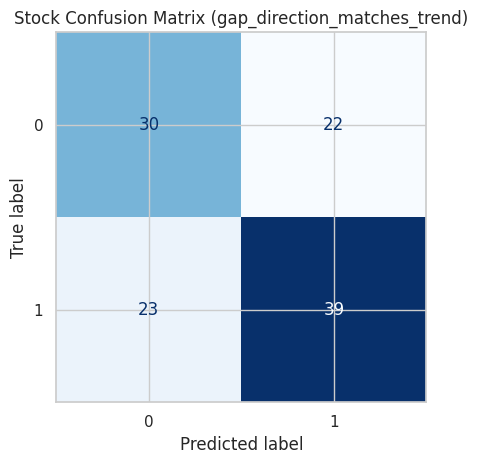

News source-group classification report:
              precision    recall  f1-score   support

   Bloomberg      0.672     0.821     0.739      2706
FOX Business      0.211     0.118     0.151       999
       Other      0.592     0.684     0.634      3832
       Yahoo      0.244     0.099     0.141       766
  Zero Hedge      0.280     0.181     0.220       852

    accuracy                          0.567      9155
   macro avg      0.400     0.381     0.377      9155
weighted avg      0.516     0.567     0.533      9155



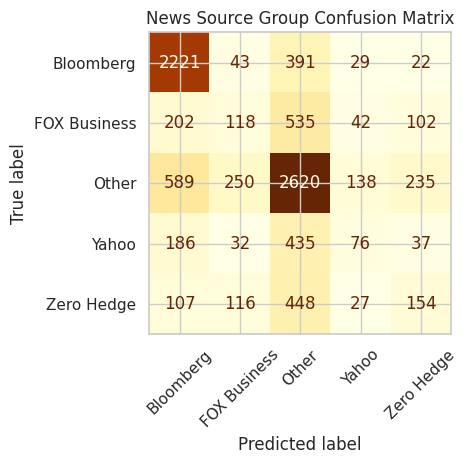

Polymarket direction classification report:
              precision    recall  f1-score   support

        DOWN      1.000     1.000     1.000        52
          UP      1.000     1.000     1.000        49

    accuracy                          1.000       101
   macro avg      1.000     1.000     1.000       101
weighted avg      1.000     1.000     1.000       101



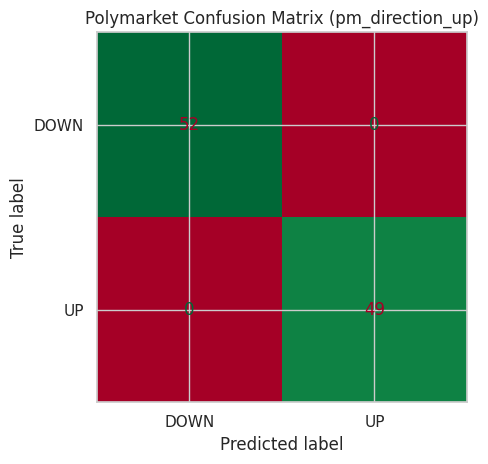

Outlier counts (stock):


,outlier_count
pre_market_gap_pct,23
volume,21
end_price,0
high,0
start_price,0
low,0
gap_direction_matches_trend,0
pre_market_volume_relative,0


Outlier counts (polymarket_daily):


,outlier_count
pm_return,10
up_price,0
open_price,0
close_price,0


In [5]:
# Step 4: Confusion matrix analysis and outlier diagnostics

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# Stock confusion matrix analysis
# Train a baseline Random Forest model to predict gap direction matches trend using stock features
stock_target = "gap_direction_matches_trend"
stock_features = [
    "start_price",
    "end_price",
    "high",
    "low",
    "volume",
    "pre_market_gap_pct",
    "pre_market_volume_relative",
]
# Keep only features that exist in the stock dataframe
stock_features = [c for c in stock_features if c in df.columns]

if stock_features and stock_target in df.columns:
    # Prepare data: remove rows with missing values and convert target to integer
    stock_model_df = df[stock_features + [stock_target]].dropna().copy()
    stock_model_df[stock_target] = pd.to_numeric(stock_model_df[stock_target], errors="coerce")
    stock_model_df = stock_model_df.dropna(subset=[stock_target])
    stock_model_df[stock_target] = stock_model_df[stock_target].astype(int)

    # Only train if we have at least 2 classes (binary classification)
    if stock_model_df[stock_target].nunique() >= 2:
        # Split data into 80% train and 20% test
        X_train, X_test, y_train, y_test = train_test_split(
            stock_model_df[stock_features],
            stock_model_df[stock_target],
            test_size=0.2,
            random_state=42,
            stratify=stock_model_df[stock_target],
        )

        # Train Random Forest classifier with 800 trees
        stock_model = RandomForestClassifier(n_estimators=800, random_state=42)
        stock_model.fit(X_train, y_train)
        stock_pred = stock_model.predict(X_test)

        # Print detailed classification metrics including precision, recall, and F1 score
        print("Stock classification report:")
        print(classification_report(y_test, stock_pred, digits=3))

        # Create and display confusion matrix visualization
        stock_cm = confusion_matrix(y_test, stock_pred, labels=[0, 1])
        stock_disp = ConfusionMatrixDisplay(stock_cm, display_labels=["0", "1"])
        stock_disp.plot(cmap="Blues", colorbar=False)
        plt.title("Stock Confusion Matrix (gap_direction_matches_trend)")
        plt.tight_layout()
        plt.show()
    else:
        print("Stock confusion matrix skipped: target has fewer than two classes after filtering.")
else:
    print("Stock confusion matrix skipped: required features/target are missing.")

# News confusion matrix analysis
# Train a baseline model to predict news source group using headline-derived features
news_model_df = news_df.copy()
# Create engineered features from headline text and timestamps
news_dt = pd.to_datetime(news_model_df["datetime"], errors="coerce")
news_model_df["headline_length"] = news_model_df["headline"].astype(str).str.len()
news_model_df["hour_of_day"] = news_dt.dt.hour
news_model_df["headline_word_count"] = news_model_df["headline"].astype(str).str.split().str.len()

# Group rare sources into 'Other' category, keeping only top 4 sources
top_sources = news_model_df["source"].value_counts().head(4).index.tolist()
news_model_df["source_group"] = news_model_df["source"].where(news_model_df["source"].isin(top_sources), "Other")
news_feature_cols = ["headline_length", "hour_of_day", "headline_word_count"]

# Remove rows with missing values in features or target
news_model_df = news_model_df.dropna(subset=news_feature_cols + ["source_group"]).copy()

# Only train if we have at least 2 source groups
if news_model_df["source_group"].nunique() >= 2:
    # Split data into 80% train and 20% test while keeping source group distribution balanced
    X_train, X_test, y_train, y_test = train_test_split(
        news_model_df[news_feature_cols],
        news_model_df["source_group"],
        test_size=0.2,
        random_state=42,
        stratify=news_model_df["source_group"],
    )

    # Train Random Forest classifier with 800 trees
    news_model = RandomForestClassifier(n_estimators=800, random_state=42)
    news_model.fit(X_train, y_train)
    news_pred = news_model.predict(X_test)

    # Get sorted list of unique source groups for consistent confusion matrix labeling
    label_order = sorted(y_test.unique().tolist())
    # Print detailed classification metrics
    print("News source-group classification report:")
    print(classification_report(y_test, news_pred, digits=3))

    # Create and display confusion matrix visualization with rotated labels
    news_cm = confusion_matrix(y_test, news_pred, labels=label_order)
    news_disp = ConfusionMatrixDisplay(news_cm, display_labels=label_order)
    news_disp.plot(cmap="YlOrBr", xticks_rotation=45, colorbar=False)
    plt.title("News Source Group Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("News confusion matrix skipped: source_group has fewer than two classes.")

# Polymarket confusion matrix analysis
# Train a baseline model to predict Polymarket direction (UP vs DOWN) using price features
poly_model_df = poly_daily_df.copy()
# Convert all numeric columns to numeric type to handle any formatting issues
for col in ["up_price", "open_price", "close_price", "pm_return", "pm_direction_up"]:
    if col in poly_model_df.columns:
        poly_model_df[col] = pd.to_numeric(poly_model_df[col], errors="coerce")

# Derive pm_return if it doesn't exist (close - open) / open
if "pm_return" not in poly_model_df.columns and {"open_price", "close_price"}.issubset(poly_model_df.columns):
    poly_model_df["pm_return"] = (
        (poly_model_df["close_price"] - poly_model_df["open_price"])
        / poly_model_df["open_price"].replace(0, np.nan)
    )

# Define target and features for Polymarket prediction
poly_target = "pm_direction_up"
poly_features = [c for c in ["up_price", "open_price", "close_price", "pm_return"] if c in poly_model_df.columns]

# Only proceed if we have features and a target variable
if poly_features and poly_target in poly_model_df.columns:
    # Prepare data: remove rows with missing values and convert target to integer
    poly_model_clean = poly_model_df[poly_features + [poly_target]].dropna().copy()
    poly_model_clean[poly_target] = pd.to_numeric(poly_model_clean[poly_target], errors="coerce")
    poly_model_clean = poly_model_clean.dropna(subset=[poly_target])
    poly_model_clean[poly_target] = poly_model_clean[poly_target].astype(int)

    # Only train if we have at least 2 classes (UP and DOWN)
    if poly_model_clean[poly_target].nunique() >= 2:
        # Split data into 80% train and 20% test while keeping direction distribution balanced
        X_train, X_test, y_train, y_test = train_test_split(
            poly_model_clean[poly_features],
            poly_model_clean[poly_target],
            test_size=0.2,
            random_state=42,
            stratify=poly_model_clean[poly_target],
        )

        # Train Random Forest classifier with 800 trees
        poly_model = RandomForestClassifier(n_estimators=800, random_state=42)
        poly_model.fit(X_train, y_train)
        poly_pred = poly_model.predict(X_test)

        # Print detailed classification metrics for Polymarket direction prediction
        print("Polymarket direction classification report:")
        print(classification_report(y_test, poly_pred, labels=[0, 1], target_names=["DOWN", "UP"], digits=3))

        # Create and display confusion matrix visualization with intuitive labels
        poly_cm = confusion_matrix(y_test, poly_pred, labels=[0, 1])
        poly_disp = ConfusionMatrixDisplay(poly_cm, display_labels=["DOWN", "UP"])
        poly_disp.plot(cmap="RdYlGn", colorbar=False)
        plt.title("Polymarket Confusion Matrix (pm_direction_up)")
        plt.tight_layout()
        plt.show()
    else:
        print("Polymarket confusion matrix skipped: target has fewer than two classes after filtering.")
else:
    print("Polymarket confusion matrix skipped: required features/target are missing.")


# Helpers for outlier detection and reporting
# Detect outliers using the Interquartile Range (IQR) method
# Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
def outlier_report_iqr(frame, cols, label):
    # Return early if no columns to analyze
    if not cols:
        print(f"No numeric columns available for {label} outlier detection.")
        return

    # Count outliers for each column
    counts = {}
    for col in cols:
        # Convert to numeric, handling any conversion errors gracefully
        series = pd.to_numeric(frame[col], errors="coerce")
        # Skip columns with no valid numeric data
        if series.dropna().empty:
            counts[col] = 0
            continue
        # Calculate quartiles and IQR
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        # Define outlier bounds
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        # Count values outside the bounds
        counts[col] = int(((series < lower) | (series > upper)).sum())

    # Create report sorted by outlier count (highest first)
    report = pd.Series(counts, name="outlier_count").sort_values(ascending=False).to_frame()
    print(f"Outlier counts ({label}):")
    display(report)

# Outlier detection for stock data using IQR method
# Get all numeric columns from stock dataframe and detect outliers
stock_outlier_cols = df.select_dtypes(include="number").columns.tolist()
outlier_report_iqr(df, stock_outlier_cols, "stock")

# Outlier detection for news data using IQR method
# Prepare Polymarket data for outlier detection
poly_for_outliers = poly_daily_df.copy()
# Convert all relevant columns to numeric type
for col in ["up_price", "open_price", "close_price", "pm_return"]:
    if col in poly_for_outliers.columns:
        poly_for_outliers[col] = pd.to_numeric(poly_for_outliers[col], errors="coerce")

# Derive pm_return if missing (for consistency with other analysis)
if "pm_return" not in poly_for_outliers.columns and {"open_price", "close_price"}.issubset(poly_for_outliers.columns):
    poly_for_outliers["pm_return"] = (
        (poly_for_outliers["close_price"] - poly_for_outliers["open_price"])
        / poly_for_outliers["open_price"].replace(0, pd.NA)
    )

# Select relevant Polymarket numeric columns and detect outliers
poly_outlier_cols = [c for c in ["up_price", "open_price", "close_price", "pm_return"] if c in poly_for_outliers.columns]
outlier_report_iqr(poly_for_outliers, poly_outlier_cols, "polymarket_daily")

### <span style="color:#9A3412;">Findings: Confusion Matrix</span>

This diagnostic step gives three different signal-quality stories, and each one has a plausible reason.

- **Stock confusion matrix (moderate performance):**
  - The model has some predictive power but clear overlap between classes.
  - Why this can happen:
    - Daily direction labels are noisy and event-driven.
    - Price-level features (`start_price`, `end_price`, `high`, `low`) are highly correlated, so they add limited independent signal.
    - Short-horizon market direction is often influenced by information not captured in OHLCV alone.

- **News source-group confusion matrix (mixed performance):**
  - Better performance on large classes, weaker on small classes.
  - Why this can happen:
    - Class imbalance (for example, `Other` vs smaller named sources) makes minority classes harder to learn.
    - Current features (`headline_length`, `headline_word_count`, `hour_of_day`) capture writing structure, not headline meaning.
    - Similar editorial styles across providers can make class boundaries fuzzy.

- **Polymarket confusion matrix (very strong performance):**
  - This result can look very strong because market-derived features often contain direct directional information.
  - Why this can happen:
    - `open_price`, `close_price`, and `pm_return` are tightly linked to `pm_direction_up` by construction.
    - If train/test split is row-based (not date-grouped), closely related intraday rows can appear in both sets.
    - Strong feature-target coupling can inflate benchmark metrics even if real forward generalization is weaker.

### What These Cases Mean Practically

- **Case A: Weak-to-moderate matrix (stock/news):**
  - Usually indicates real overlap/noise, missing explanatory features, or imbalance.
  - Next step: add richer features (returns/volatility regimes, sentiment semantics, temporal context) and compare class-balanced metrics.

- **Case B: Very high matrix (polymarket):**
  - Can indicate a genuinely strong signal, but can also indicate leakage-like structure or split contamination.
  - Next step: validate with stricter evaluation: time-based split, group-by-date split, leakage-safe feature set, and stability checks across different windows.

### Recommended Steps to be taken

- Treat these models as **diagnostic baselines**, not final production evidence.
- The confusion matrices are still valuable because they reveal where errors concentrate and whether each dataset contributes distinct signal.
- Final modeling decisions should be based on leakage-safe validation and out-of-time performance, not one split.

---

# Final Takeaway

Combining stock context, news semantics, and Polymarket dynamics is promising. However, further analysis and engineering has to be done!

## <span style="color:#B45309;">D2.3: Data Wrangling and Imputation</span>

### Step 5: Clean Missing Features, Build One Combined CSV, and Demonstrate Imputation
The main pipeline creates a single clean daily table by merging stock context, Polymarket daily labels, and news metadata aggregates. Missing numeric values are imputed with a data-aware strategy: near-symmetric numeric columns use mean and skewed numeric columns use median. Categorical values are left unchanged. To show the numeric imputation decision process clearly for grading, this step also creates a synthetic dirty copy of the stock prices table, randomly removes values from a small set of numeric columns, and imputes them using the previous EDA analysis.

In [10]:
# Step 5: Missing-feature imputation and one-file consolidation
# This step builds one clean merged table and then demonstrates imputation on a separate dirty copy.
from pathlib import Path
import json

import numpy as np
import pandas as pd

# Resolve the project root relative to the notebook so the cell works from different launch locations.
project_root = Path("..")
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"

# Ensure the output folder exists before writing the cleaned dataset and audit logs.
processed_dir.mkdir(parents=True, exist_ok=True)

stock_json_path = raw_dir / "NVDA_prices_features_2024-01-01_to_2026-04-13.json"
news_json_path = raw_dir / "finviz_2426.json"
poly_daily_path = processed_dir / "polymarket_master_dataset_h60m.csv"

combined_clean_path = processed_dir / "nvda_multimodal_clean_imputed.csv"
imputation_log_path = processed_dir / "nvda_imputation_decisions.csv"

# Stop early if the canonical Polymarket file is missing, because the merge depends on it.
if not poly_daily_path.exists():
    raise FileNotFoundError(
        f"Missing Polymarket daily file: {poly_daily_path}. Run D2.1.1 first."
    )

# Load the raw stock and news JSON files, plus the canonical Polymarket daily CSV.
with open(stock_json_path, "r", encoding="utf-8") as f:
    stock_records = json.load(f)
with open(news_json_path, "r", encoding="utf-8") as f:
    news_records = json.load(f)

stock_raw = pd.DataFrame(stock_records)
news_raw = pd.DataFrame(news_records)
poly_raw = pd.read_csv(poly_daily_path)

# Stock daily aggregates
# Convert the intraday stock records into one row per trade date.
stock_raw["trade_date"] = pd.to_datetime(stock_raw["datetime"], errors="coerce").dt.date
stock_daily = (
    stock_raw.dropna(subset=["trade_date"])
    .sort_values("trade_date")
    .drop_duplicates(subset=["trade_date"], keep="last")
    .reset_index(drop=True)
)

# Keep only the stock features that actually exist in the source file.
stock_feature_cols = [
    "start_price",
    "end_price",
    "high",
    "low",
    "volume",
    "pre_market_gap_pct",
    "pre_market_volume_relative",
    "gap_direction_matches_trend",
]
stock_feature_cols = [c for c in stock_feature_cols if c in stock_daily.columns]

# Convert the selected stock features to numeric so imputation and modeling behave consistently.
for col in stock_feature_cols:
    stock_daily[col] = pd.to_numeric(stock_daily[col], errors="coerce")
stock_daily = stock_daily[["trade_date"] + stock_feature_cols]

# News daily aggregates
# Collapse the raw news records to daily summary features that can join to the market tables.
news_raw["trade_date"] = pd.to_datetime(news_raw["datetime"], errors="coerce").dt.date
news_raw["headline"] = news_raw.get(
    "headline", pd.Series(index=news_raw.index, dtype="object")
).astype(str)
news_raw["source"] = news_raw.get(
    "source", pd.Series(index=news_raw.index, dtype="object")
).astype(str)
news_raw["headline_length"] = news_raw["headline"].str.len()

# Keep the raw headline text in one daily column so the final CSV carries both the text and the summary features.
def combine_headlines(series):
    values = [str(item).strip() for item in series.dropna().tolist() if str(item).strip()]
    return " || ".join(values) if values else ""

# Use the most common source for the day as a simple, readable summary feature.
def dominant_source(series):
    mode = series.dropna().mode()
    return mode.iloc[0] if not mode.empty else "Unknown"

news_daily = (
    news_raw.dropna(subset=["trade_date"])
    .groupby("trade_date", as_index=False)
    .agg(
        headlines=("headline", combine_headlines),
        headline_count=("headline", "count"),
        unique_source_count=("source", "nunique"),
        avg_headline_length=("headline_length", "mean"),
        median_headline_length=("headline_length", "median"),
        max_headline_length=("headline_length", "max"),
        dominant_source=("source", dominant_source),
    )
)

# --- Polymarket daily labels ---
# Normalize the Polymarket schema so we always have a trade_date column to join on.
if "trade_date" in poly_raw.columns:
    poly_raw["trade_date"] = pd.to_datetime(poly_raw["trade_date"], errors="coerce").dt.date
elif "date" in poly_raw.columns:
    poly_raw["trade_date"] = pd.to_datetime(poly_raw["date"], errors="coerce").dt.date
elif "timestamp_et" in poly_raw.columns:
    poly_raw["trade_date"] = pd.to_datetime(poly_raw["timestamp_et"], errors="coerce").dt.date
else:
    poly_raw["trade_date"] = pd.NaT

# Convert Polymarket price and label fields to numeric form when they are present.
for col in ["up_price", "open_price", "close_price", "pm_return", "pm_direction_up", "target_up_move_h60m"]:
    if col in poly_raw.columns:
        poly_raw[col] = pd.to_numeric(poly_raw[col], errors="coerce")

# Order the Polymarket rows so the daily open/close logic stays deterministic.
poly_work = poly_raw.dropna(subset=["trade_date"]).copy()
if "timestamp_et" in poly_work.columns:
    poly_work["timestamp_et"] = pd.to_datetime(poly_work["timestamp_et"], errors="coerce")
    poly_work = poly_work.sort_values(["trade_date", "timestamp_et"])
else:
    poly_work = poly_work.sort_values("trade_date")

# Preserve explicit open and close prices when the canonical columns already exist.
if {"open_price", "close_price"}.issubset(poly_work.columns):
    poly_daily = (
        poly_work.drop_duplicates(subset=["trade_date"], keep="last")
        .reset_index(drop=True)
    )
# Otherwise, backfill open/close prices from the observed up_price series.
elif "up_price" in poly_work.columns:
    agg_dict = {
        "open_price": ("up_price", "first"),
        "close_price": ("up_price", "last"),
    }
    if "event_query" in poly_work.columns:
        agg_dict["event_query"] = ("event_query", "last")
    if "matched_event" in poly_work.columns:
        agg_dict["matched_event"] = ("matched_event", "last")
    poly_daily = poly_work.groupby("trade_date", as_index=False).agg(**agg_dict)
else:
    poly_daily = poly_work.drop_duplicates(subset=["trade_date"], keep="last").reset_index(drop=True)

# Derive the return and direction label when they are missing from the source table.
if "pm_return" not in poly_daily.columns and {"open_price", "close_price"}.issubset(poly_daily.columns):
    poly_daily["pm_return"] = (
        (poly_daily["close_price"] - poly_daily["open_price"])
        / poly_daily["open_price"].replace(0, np.nan)
    )
if "pm_direction_up" not in poly_daily.columns:
    if "target_up_move_h60m" in poly_daily.columns:
        poly_daily["pm_direction_up"] = poly_daily["target_up_move_h60m"]
    elif {"open_price", "close_price"}.issubset(poly_daily.columns):
        poly_daily["pm_direction_up"] = np.where(
            poly_daily[["open_price", "close_price"]].notna().all(axis=1),
            (poly_daily["close_price"] > poly_daily["open_price"]).astype(int),
            np.nan,
        )
    else:
        poly_daily["pm_direction_up"] = np.nan

# Keep only the columns needed for the merge and the downstream diagnostics.
poly_keep_cols = [
    "trade_date",
    "open_price",
    "close_price",
    "pm_return",
    "pm_direction_up",
    "event_query",
    "matched_event",
]
poly_keep_cols = [c for c in poly_keep_cols if c in poly_daily.columns]
poly_daily = poly_daily[poly_keep_cols]

# Combine the datasets on trade_date, starting with the stock data and then adding Polymarket and news features.
combined = stock_daily.merge(poly_daily, on="trade_date", how="left")
combined = combined.merge(news_daily, on="trade_date", how="left")

# Keep a transparent flag showing which rows actually have Polymarket label coverage.
combined["has_polymarket_label"] = combined["pm_direction_up"].notna().astype(int)

imputation_rows = []

# Numeric imputation based on skewness.
# We use mean for roughly symmetric columns and median for skewed columns.
numeric_cols = combined.select_dtypes(include="number").columns.tolist()
exclude_numeric = {"pm_direction_up", "pm_return", "has_polymarket_label"}
numeric_impute_cols = [c for c in numeric_cols if c not in exclude_numeric]

# Fill missing numeric values one column at a time so the strategy can be logged and reviewed.
for col in numeric_impute_cols:
    missing_count = int(combined[col].isna().sum())
    if missing_count == 0:
        continue

    # Work only with the observed values when deciding whether mean or median is more appropriate.
    non_null = combined[col].dropna()
    if non_null.empty:
        continue

    # Measure skewness so we can choose a robust fill method for this feature.
    skewness = float(non_null.skew()) if len(non_null) >= 3 else 0.0
    strategy = "median" if abs(skewness) >= 1.0 else "mean"
    # Compute the replacement value that will be used to fill the NaNs.
    fill_value = float(non_null.median() if strategy == "median" else non_null.mean())

    # Replace NaNs in this numeric column with the selected statistic.
    combined[col] = combined[col].fillna(fill_value)
    # Record the decision so the clean-up step remains auditable.
    imputation_rows.append(
        {
            "column": col,
            "dtype": "numeric",
            "missing_filled": missing_count,
            "skewness": round(skewness, 6),
            "strategy": strategy,
            "fill_value": fill_value,
        }
    )

# Leave categorical values as-is; only numeric columns are imputed in this step.
# This keeps raw text fields and category labels available for downstream inspection.

# Restore the Polymarket label to an integer-like nullable type for easier modeling.
if "pm_direction_up" in combined.columns:
    combined["pm_direction_up"] = combined["pm_direction_up"].round().astype("Int64")

# Sort the final clean table chronologically so it is easy to inspect and reuse.
combined["trade_date"] = pd.to_datetime(combined["trade_date"], errors="coerce")
combined = combined.sort_values("trade_date").reset_index(drop=True)
combined["trade_date"] = combined["trade_date"].dt.strftime("%Y-%m-%d")

# Convert the imputation decisions into a compact audit table and save both outputs.
imputation_log = pd.DataFrame(imputation_rows)
if imputation_log.empty:
    imputation_log = pd.DataFrame(
        columns=["column", "dtype", "missing_filled", "skewness", "strategy", "fill_value"]
    )

combined.to_csv(combined_clean_path, index=False)
imputation_log.to_csv(imputation_log_path, index=False)

# Report what, if anything, is still missing after the main imputation pass.
remaining_missing_numeric = int(combined[numeric_impute_cols].isna().sum().sum()) if numeric_impute_cols else 0
remaining_missing_total = int(combined.isna().sum().sum())
feature_cols_for_missing = [c for c in combined.columns if c not in ["pm_direction_up", "pm_return"]]
remaining_feature_missing = int(combined[feature_cols_for_missing].isna().sum().sum())

# Print a short summary so the notebook output explains what was created and where it was saved.
print(f"Combined rows: {len(combined)}")
print(f"Combined columns: {len(combined.columns)}")
print(f"Polymarket source used: {poly_daily_path.name}")
print(f"Saved clean combined dataset: {combined_clean_path}")
print(f"Saved imputation log: {imputation_log_path}")
print(f"Numeric missing values after imputation: {remaining_missing_numeric}")
print(f"Feature missing values after imputation (excluding label columns): {remaining_feature_missing}")
print(f"Total remaining missing values (label gaps included): {remaining_missing_total}")

# Show a preview of the audit log and the cleaned table for quick inspection.
display(imputation_log.head(15))
display(combined.head())

# CREATING DIRTY DATA FOR GRADING PURPOSES
# This demo does not overwrite the canonical merged output; it only shows how the stock table is imputed after synthetic missingness is introduced.
# The goal is to make the missing-value cleanup process visible end to end.
stock_dirty = stock_daily.copy()

# Use a fixed seed so the demo is repeatable.
demo_rng = np.random.default_rng(42)

# Focus the demo on a small set of numeric columns so the imputation example stays simple.
demo_numeric_cols = [c for c in ["start_price", "volume", "pre_market_gap_pct"] if c in stock_dirty.columns]

# Blank out a small random subset of each selected numeric column.
for col in demo_numeric_cols:
    missing_mask = demo_rng.random(len(stock_dirty)) < 0.12
    stock_dirty.loc[missing_mask, col] = np.nan

# Make a separate copy for the cleaned result so the dirty source stays unchanged.
stock_dirty_imputed = stock_dirty.copy()
stock_dirty_log = []

# Use the EDA findings to choose the fill strategy: mean for near-symmetric columns and median for skewed columns.
# The next line replaces NaN values directly with the chosen statistic for each selected column.
for col in demo_numeric_cols:
    # Count how many missing values need to be filled in this column.
    missing_count = int(stock_dirty_imputed[col].isna().sum())
    if missing_count == 0:
        continue

    # Work only with the observed values when deciding whether mean or median is more appropriate.
    non_null = stock_dirty_imputed[col].dropna()
    if non_null.empty:
        continue

    # Measure skewness so we can choose a robust fill method for this feature.
    skewness = float(non_null.skew()) if len(non_null) >= 3 else 0.0
    if col == "volume" or abs(skewness) >= 1.0:
        strategy = "median"
    else:
        strategy = "mean"
    # Compute the replacement value that will be used to fill the NaNs.
    fill_value = float(non_null.median() if strategy == "median" else non_null.mean())
    # Replace the missing values in this column with the selected fill value.
    stock_dirty_imputed[col] = stock_dirty_imputed[col].fillna(fill_value)
    # Record the decision so the demo remains auditable.
    stock_dirty_log.append({
        "column": col,
        "dtype": "numeric",
        "missing_filled": missing_count,
        "skewness": round(skewness, 6),
        "strategy": strategy,
        "fill_value": fill_value,
        "reason": "median for skewed or high-variance series; mean for tighter, more symmetric series",
    })

# Save the small demo result and its log for inspection.
stock_dirty_log_df = pd.DataFrame(stock_dirty_log)
stock_dirty_path = processed_dir / "nvda_stock_dirty_imputed_demo.csv"
stock_dirty_log_path = processed_dir / "nvda_stock_dirty_imputation_log.csv"
stock_dirty_imputed.to_csv(stock_dirty_path, index=False)
stock_dirty_log_df.to_csv(stock_dirty_log_path, index=False)

# Print and display the demo outputs so the notebook reader can see the result immediately.
print(f"Dirty stock demo rows: {len(stock_dirty_imputed)}")
print(f"Saved dirty stock demo dataset: {stock_dirty_path}")
print(f"Saved dirty stock imputation log: {stock_dirty_log_path}")
display(stock_dirty_log_df)
display(stock_dirty_imputed.head())

Combined rows: 570
Combined columns: 23
Polymarket source used: polymarket_master_dataset_h60m.csv
Saved clean combined dataset: ../data/processed/nvda_multimodal_clean_imputed.csv
Saved imputation log: ../data/processed/nvda_imputation_decisions.csv
Numeric missing values after imputation: 0
Feature missing values after imputation (excluding label columns): 1290
Total remaining missing values (label gaps included): 2194


,column,dtype,missing_filled,skewness,strategy,fill_value
0,pre_market_gap_pct,numeric,1,-0.846260,mean,0.002684
1,open_price,numeric,452,-0.092663,mean,0.536284
2,close_price,numeric,452,-0.176717,mean,0.539432
3,headline_count,numeric,193,0.097042,mean,114.575597
4,unique_source_count,numeric,193,-1.961553,median,18.000000
5,avg_headline_length,numeric,193,-1.354259,median,63.157895
6,median_headline_length,numeric,193,-1.055208,median,63.000000
7,max_headline_length,numeric,193,0.605902,mean,114.098143


,trade_date,start_price,end_price,high,low,volume,pre_market_gap_pct,pre_market_volume_relative,gap_direction_matches_trend,open_price,...,event_query,matched_event,headlines,headline_count,unique_source_count,avg_headline_length,median_headline_length,max_headline_length,dominant_source,has_polymarket_label
0,2024-01-02,49.213912,48.138569,49.264879,47.565921,411254000,0.002684,1.0,1,0.536284,...,NaN,NaN,NaN,114.575597,18.0,63.157895,63.0,114.098143,NaN,0
1,2024-01-03,47.455988,47.539936,48.154558,47.291088,320896000,-0.014180,1.0,1,0.536284,...,NaN,NaN,NaN,114.575597,18.0,63.157895,63.0,114.098143,NaN,0
2,2024-01-04,47.737816,47.968678,48.470370,47.478975,306535000,0.004162,1.0,0,0.536284,...,NaN,NaN,Only Citizens Should Vote In America: Gingrich,1.000000,1.0,46.000000,46.0,46.000000,Zero Hedge,0
3,2024-01-05,48.432395,49.067005,49.516731,48.276488,415039000,0.009667,1.0,0,0.536284,...,NaN,NaN,Shares in Asia Mixed as Fed Rate-Cut Bets Trim...,19.000000,9.0,64.052632,68.0,98.000000,Zero Hedge,0
4,2024-01-08,49.481761,52.221085,52.243074,49.448781,642510000,0.008453,1.0,0,0.536284,...,NaN,NaN,NaN,114.575597,18.0,63.157895,63.0,114.098143,NaN,0


Dirty stock demo rows: 570
Saved dirty stock demo dataset: ../data/processed/nvda_stock_dirty_imputed_demo.csv
Saved dirty stock imputation log: ../data/processed/nvda_stock_dirty_imputation_log.csv


,column,dtype,missing_filled,skewness,strategy,fill_value,reason
0,start_price,numeric,71,-0.188158,mean,1.367250e+02,median for skewed or high-variance series; mea...
1,volume,numeric,65,1.619156,median,2.265425e+08,median for skewed or high-variance series; mea...
2,pre_market_gap_pct,numeric,64,-0.433953,mean,3.098923e-03,median for skewed or high-variance series; mea...


,trade_date,start_price,end_price,high,low,volume,pre_market_gap_pct,pre_market_volume_relative,gap_direction_matches_trend
0,2024-01-02,49.213912,48.138569,49.264879,47.565921,411254000.0,0.003099,1.0,1
1,2024-01-03,47.455988,47.539936,48.154558,47.291088,320896000.0,-0.014180,1.0,1
2,2024-01-04,47.737816,47.968678,48.470370,47.478975,306535000.0,0.004162,1.0,0
3,2024-01-05,48.432395,49.067005,49.516731,48.276488,415039000.0,0.009667,1.0,0
4,2024-01-08,136.724976,52.221085,52.243074,49.448781,642510000.0,0.008453,1.0,0


### <span style="color:#92400E;">Findings: D2.3 Cleaning and Imputation</span>

A clean multimodal CSV is produced first with explicit, auditable numeric imputation choices. The strategy is data-driven per numeric column: skewed numeric features use median, while near-symmetric numeric features use mean. Categorical values are left unchanged.
</div>

- The notebook first exports the intermediate clean file: `data/processed/nvda_multimodal_clean_imputed.csv`.
- Every numeric imputation decision is logged to `data/processed/nvda_imputation_decisions.csv` for reproducibility and review.
- `has_polymarket_label` is retained so sparse target coverage remains transparent rather than hidden.
- A separate dirty-stock demo is also created in this step to show how mean and median are selected after synthetic missingness is introduced.
- The demo is intentionally small and focuses on three numeric columns only: `start_price`, `volume`, and `pre_market_gap_pct`.
- The raw headline text is still present in the intermediate file at this stage, but it is removed later in Step 6 when the final multimodal CSV is created with FinBERT sentiment scores.

## <span style="color:#7C3AED;">D2.4: FinBERT Sentiment </span>

### Step 6: Add FinBERT Sentiment to Every Headline
This step scores each Finviz headline with FinBERT and stores the sentiment probabilities and label at headline level. The headline table intentionally remains much denser than stock and Polymarket daily tables.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Headlines scored with FinBERT: 45775
Daily sentiment timeline rows: 466
Saved headline sentiment file: ../data/processed/finbert_headline_sentiment.csv
Saved daily timeline file: ../data/processed/finbert_daily_timeline.csv
Saved final multimodal dataset: ../data/processed/nvda_multimodal_final.csv
The final CSV keeps the merged stock, Polymarket, news summary, and FinBERT sentiment features, but drops raw headline text.


,datetime,headline,source,trade_date,positive_prob,neutral_prob,negative_prob,finbert_score,sentiment_label
0,2023-12-29 01:29:00,Patriot Battery Metals: An Amazing Lithium Dep...,Seeking Alpha,2023-12-29,0.403723,0.587615,0.008662,0.395061,neutral
1,2023-12-29 06:42:00,I love predictions,Angry Bear,2023-12-29,0.107374,0.871167,0.021458,0.085916,neutral
2,2023-12-29 07:00:00,Major Tsunami Warning Issued In Japan After Po...,Zero Hedge,2023-12-29,0.083964,0.158291,0.757746,-0.673782,negative
3,2023-12-29 07:15:00,Police Injured During 'Diversity Riot' In London,Zero Hedge,2023-12-29,0.040407,0.093882,0.865711,-0.825303,negative
4,2023-12-29 07:40:00,"""First Time In Nearly 2 Years"": Snow Drought I...",Zero Hedge,2023-12-29,0.014505,0.069228,0.916267,-0.901763,negative


,trade_date,headline_count,positive_prob_mean,neutral_prob_mean,negative_prob_mean,finbert_score_mean,finbert_score_std,positive_share,neutral_share,negative_share
0,2023-12-29,5,0.129995,0.356037,0.513969,-0.383974,0.586208,0.000000,0.400000,0.600000
1,2024-01-01,14,0.242204,0.390584,0.367212,-0.125008,0.649211,0.214286,0.428571,0.357143
2,2024-01-04,1,0.045816,0.928787,0.025397,0.020419,0.000000,0.000000,1.000000,0.000000
3,2024-01-05,19,0.103428,0.554893,0.341679,-0.238251,0.418614,0.052632,0.526316,0.421053
4,2024-01-07,37,0.199145,0.374905,0.425950,-0.226806,0.597012,0.162162,0.405405,0.432432


,trade_date,finbert_score_mean,positive_prob_mean,negative_prob_mean
0,2024-01-02,NaN,NaN,NaN
1,2024-01-03,NaN,NaN,NaN
2,2024-01-04,0.020419,0.045816,0.025397
3,2024-01-05,-0.238251,0.103428,0.341679
4,2024-01-08,NaN,NaN,NaN


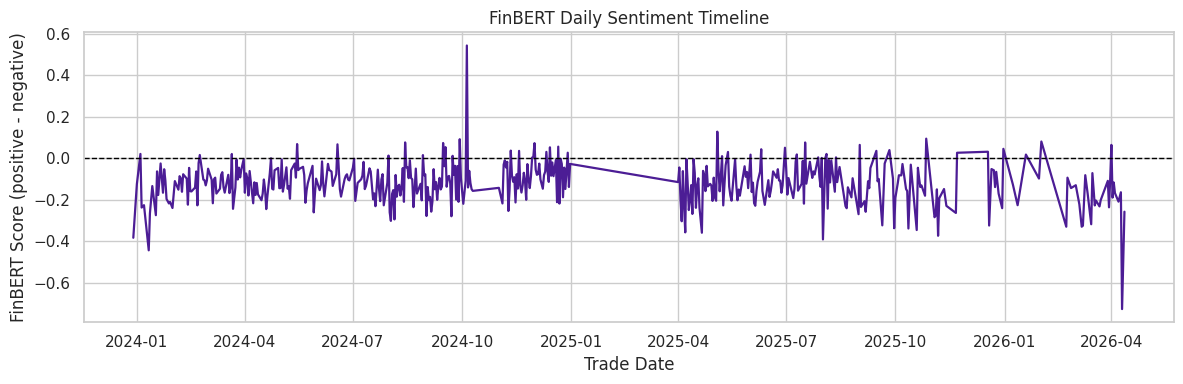

In [13]:
# Step 6: FinBERT sentiment scoring and final multimodal export
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from transformers import pipeline

# Use the same project folder layout as the earlier notebook steps.
project_root = Path("..")
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# Step 6 reads the raw news archive for scoring, then merges the sentiment outputs into the Step 5 multimodal table.
news_json_path = raw_dir / "finviz_2426.json"
combined_input_path = processed_dir / "nvda_multimodal_clean_imputed.csv"
headline_sentiment_path = processed_dir / "finbert_headline_sentiment.csv"
daily_timeline_path = processed_dir / "finbert_daily_timeline.csv"
final_dataset_path = processed_dir / "nvda_multimodal_final.csv"

# The final sentiment merge depends on the cleaned Step 5 dataset.
if not combined_input_path.exists():
    raise FileNotFoundError(
        f"Missing combined multimodal input file: {combined_input_path}. Run Step 5 first."
    )

# Load the intermediate multimodal table that already contains stock, Polymarket, and news summary features.
combined_input_df = pd.read_csv(combined_input_path)
combined_input_df["trade_date"] = pd.to_datetime(combined_input_df["trade_date"], errors="coerce")

# Reload the raw news records so FinBERT can score the original headlines directly.
with open(news_json_path, "r", encoding="utf-8") as f:
    news_records = json.load(f)

headline_df = pd.DataFrame(news_records).copy()

# These are the minimum fields needed to score headlines and align the results by date.
required_cols = ["datetime", "headline", "source"]
for col in required_cols:
    if col not in headline_df.columns:
        if col == "source":
            headline_df[col] = "Unknown"
        else:
            raise ValueError(f"Missing required news column: {col}")

# Clean the headline text and timestamps before sending them through the sentiment model.
headline_df["datetime"] = pd.to_datetime(headline_df["datetime"], errors="coerce")
headline_df["headline"] = headline_df["headline"].astype(str).str.strip()
headline_df["source"] = headline_df["source"].astype(str).str.strip().replace("", "Unknown")

# Drop rows that cannot be scored or aligned to a date.
headline_df = headline_df[
    headline_df["datetime"].notna() & headline_df["headline"].ne("")
]
headline_df = headline_df.sort_values("datetime").reset_index(drop=True)
headline_df["trade_date"] = headline_df["datetime"].dt.date

if headline_df.empty:
    raise ValueError("No valid headlines available for FinBERT scoring.")

# Load FinBERT as a three-class sentiment classifier.
sentiment_pipe = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    top_k=None,
)

# Convert the model's label/score output into fixed positive, neutral, and negative probability columns.
def parse_probabilities(model_output):
    probs = {"positive_prob": 0.0, "neutral_prob": 0.0, "negative_prob": 0.0}
    for row in model_output:
        label = str(row.get("label", "")).lower()
        key = f"{label}_prob"
        if key in probs:
            probs[key] = float(row.get("score", 0.0))
    return probs

# Score every headline in batches so the run stays manageable.
model_outputs = sentiment_pipe(
    headline_df["headline"].tolist(),
    truncation=True,
    batch_size=32,
)
probs_df = pd.DataFrame([parse_probabilities(item) for item in model_outputs])

# Combine the original headline rows with the FinBERT probabilities and a simple sentiment label.
headline_sentiment_df = pd.concat([headline_df.reset_index(drop=True), probs_df], axis=1)
headline_sentiment_df["finbert_score"] = (
    headline_sentiment_df["positive_prob"] - headline_sentiment_df["negative_prob"]
)
headline_sentiment_df["sentiment_label"] = (
    headline_sentiment_df[["positive_prob", "neutral_prob", "negative_prob"]]
    .idxmax(axis=1)
    .str.replace("_prob", "", regex=False)
)

# Collapse the headline-level scores to one row per trade date for the final merge.
daily_timeline = (
    headline_sentiment_df.groupby("trade_date", as_index=False)
    .agg(
        headline_count=("headline", "count"),
        positive_prob_mean=("positive_prob", "mean"),
        neutral_prob_mean=("neutral_prob", "mean"),
        negative_prob_mean=("negative_prob", "mean"),
        finbert_score_mean=("finbert_score", "mean"),
        finbert_score_std=("finbert_score", "std"),
        positive_share=("sentiment_label", lambda s: (s == "positive").mean()),
        neutral_share=("sentiment_label", lambda s: (s == "neutral").mean()),
        negative_share=("sentiment_label", lambda s: (s == "negative").mean()),
    )
    .sort_values("trade_date")
)
daily_timeline["finbert_score_std"] = daily_timeline["finbert_score_std"].fillna(0.0)

# Save the headline-level and daily sentiment outputs for inspection or reuse.
headline_sentiment_df.to_csv(headline_sentiment_path, index=False)
daily_timeline.to_csv(daily_timeline_path, index=False)

# Merge the daily sentiment features into the existing multimodal table.
daily_timeline["trade_date"] = pd.to_datetime(daily_timeline["trade_date"], errors="coerce")
final_dataset_df = combined_input_df.merge(daily_timeline, on="trade_date", how="left")

# The headline text is no longer needed once sentiment has been computed, so remove it from the final output.
if "headlines" in final_dataset_df.columns:
    final_dataset_df = final_dataset_df.drop(columns=["headlines"])

# Sort and write the final multimodal dataset as a single clean CSV.
final_dataset_df["trade_date"] = pd.to_datetime(final_dataset_df["trade_date"], errors="coerce")
final_dataset_df = final_dataset_df.sort_values("trade_date").reset_index(drop=True)
final_dataset_df["trade_date"] = final_dataset_df["trade_date"].dt.strftime("%Y-%m-%d")
final_dataset_df.to_csv(final_dataset_path, index=False)

print(f"Headlines scored with FinBERT: {len(headline_sentiment_df)}")
print(f"Daily sentiment timeline rows: {len(daily_timeline)}")
print(f"Saved headline sentiment file: {headline_sentiment_path}")
print(f"Saved daily timeline file: {daily_timeline_path}")
print(f"Saved final multimodal dataset: {final_dataset_path}")
print("The final CSV keeps the merged stock, Polymarket, news summary, and FinBERT sentiment features, but drops raw headline text.")

# Show small previews so the reader can verify the scoring and the final merge.
preview_cols = [c for c in ["trade_date", "finbert_score_mean", "positive_prob_mean", "negative_prob_mean", "headline_count"] if c in final_dataset_df.columns]
display(headline_sentiment_df.head())
display(daily_timeline.head())
display(final_dataset_df[preview_cols].head())

# Plot the average daily sentiment score to make the output easier to interpret visually.
plt.figure(figsize=(12, 4))
plt.plot(daily_timeline["trade_date"], daily_timeline["finbert_score_mean"], color="#4C1D95", linewidth=1.6)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.title("FinBERT Daily Sentiment Timeline")
plt.xlabel("Trade Date")
plt.ylabel("FinBERT Score (positive - negative)")
plt.tight_layout()
plt.show()

### <span style="color:#6D28D9;">Findings: D2.4 FinBERT Headline Sentiment</span>

FinBERT is now applied to the raw headline corpus, but the final exported multimodal CSV keeps only the daily sentiment scores and summary features. The raw headline text is intentionally removed from the final output because it is no longer needed downstream.
</div>

- Output file `data/processed/finbert_headline_sentiment.csv` stores sentiment probabilities and labels for each headline.
- Output file `data/processed/finbert_daily_timeline.csv` provides daily sentiment aggregation for date-level joins.
- Final output file `data/processed/nvda_multimodal_final.csv` combines stock, Polymarket, news summary features, and FinBERT sentiment scores into one dataset.
- The final CSV does not include raw headline text; that text is only used to compute sentiment and is then dropped.


This step re-checks the final multimodal CSV, removes redundant/non-beneficial columns for supervised training, and exports a model-ready version while keeping the original final CSV unchanged.

Input rows: 570
Input columns: 31


,trade_date,start_price,end_price,high,low,volume,pre_market_gap_pct,pre_market_volume_relative,gap_direction_matches_trend,open_price,...,has_polymarket_label,headline_count_y,positive_prob_mean,neutral_prob_mean,negative_prob_mean,finbert_score_mean,finbert_score_std,positive_share,neutral_share,negative_share
0,2024-01-02,49.213912,48.138569,49.264879,47.565921,411254000,0.002684,1.0,1,0.536284,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-03,47.455988,47.539936,48.154558,47.291088,320896000,-0.014180,1.0,1,0.536284,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-04,47.737816,47.968678,48.470370,47.478975,306535000,0.004162,1.0,0,0.536284,...,0,1.0,0.045816,0.928787,0.025397,0.020419,0.000000,0.000000,1.000000,0.000000
3,2024-01-05,48.432395,49.067005,49.516731,48.276488,415039000,0.009667,1.0,0,0.536284,...,0,19.0,0.103428,0.554893,0.341679,-0.238251,0.418614,0.052632,0.526316,0.421053
4,2024-01-08,49.481761,52.221085,52.243074,49.448781,642510000,0.008453,1.0,0,0.536284,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Top missingness (%):


,missing_pct
pm_direction_up,79.30
event_query,79.30
matched_event,79.30
pm_return,79.30
positive_share,33.86
negative_share,33.86
neutral_share,33.86
positive_prob_mean,33.86
neutral_prob_mean,33.86
negative_prob_mean,33.86



Model-ready rows: 118
Model-ready columns: 19
Saved model-ready dataset: ../data/processed/nvda_multimodal_final_model_ready.csv
Saved feature-drop log: ../data/processed/nvda_multimodal_feature_drop_log.csv

Dropped columns (if any):


,column,reason,detail
1,event_query,categorical_text_not_encoded,Dropped cuz already have numeric sentiment fea...
2,matched_event,categorical_text_not_encoded,Dropped cuz already have numeric sentiment fea...
3,dominant_source,categorical_text_not_encoded,Dropped cuz already have numeric sentiment fea...
4,headline_count_y,duplicate_headline_count,Kept headline_count_x (lower missingness)
5,high,high_correlation,|corr|=0.956 with start_price
6,low,high_correlation,|corr|=0.943 with start_price
7,unique_source_count,high_correlation,|corr|=0.913 with headline_count_x
8,positive_share,high_correlation,|corr|=0.980 with positive_prob_mean
9,neutral_share,high_correlation,|corr|=0.968 with neutral_prob_mean
10,negative_share,high_correlation,|corr|=0.964 with negative_prob_mean


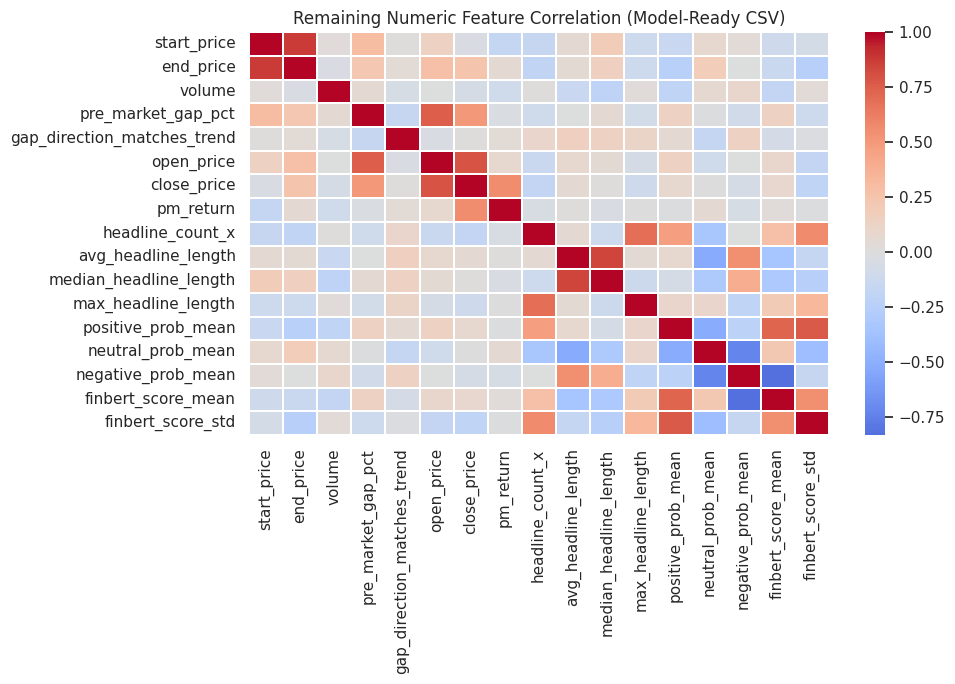

In [15]:
# Step 7: Final CSV EDA and simple feature-pruning for model training
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the final multimodal CSV produced in Step 6.
project_root = Path("..")
processed_dir = project_root / "data" / "processed"
final_csv_path = processed_dir / "nvda_multimodal_final.csv"
model_ready_path = processed_dir / "nvda_multimodal_final_model_ready.csv"
drop_log_path = processed_dir / "nvda_multimodal_feature_drop_log.csv"

if not final_csv_path.exists():
    raise FileNotFoundError(f"Missing file: {final_csv_path}. Run Step 6 first.")

final_df = pd.read_csv(final_csv_path)
print(f"Input rows: {len(final_df)}")
print(f"Input columns: {len(final_df.columns)}")
display(final_df.head())

TARGET_COL = "pm_direction_up"
CORR_THRESHOLD = 0.90
DROP_CATEGORICAL_TEXT = True

if TARGET_COL not in final_df.columns:
    raise ValueError(f"Target column not found: {TARGET_COL}")

# Keep a clean working copy and normalize key dtypes.
work_df = final_df.copy()
work_df["trade_date"] = pd.to_datetime(work_df.get("trade_date"), errors="coerce")
work_df[TARGET_COL] = pd.to_numeric(work_df[TARGET_COL], errors="coerce")

# Show missingness .
missing_ratio = (work_df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("\nTop missingness (%):")
display(missing_ratio.to_frame("missing_pct").head(20))

drop_records = []

# Supervised training needs labeled rows, so keep only rows where target exists.
before_rows = len(work_df)
work_df = work_df[work_df[TARGET_COL].notna()].copy()
drop_records.append(
    {"column": "__rows__", "reason": "drop_unlabeled_rows", "detail": f"{before_rows - len(work_df)} rows removed"}
 )

# Drop text/categorical columns for a simple numeric-first training table.
if DROP_CATEGORICAL_TEXT:
    text_cols = [c for c in ["event_query", "matched_event", "dominant_source"] if c in work_df.columns]
    if text_cols:
        work_df = work_df.drop(columns=text_cols)
        for col in text_cols:
            drop_records.append(
                {"column": col, "reason": "categorical_text_not_encoded", "detail": "Dropped cuz already have numeric sentiment features"}
            )

# If both headline count versions exist, keep the one with fewer missing values.
if {"headline_count_x", "headline_count_y"}.issubset(work_df.columns):
    miss_x = work_df["headline_count_x"].isna().mean()
    miss_y = work_df["headline_count_y"].isna().mean()
    drop_col = "headline_count_x" if miss_x > miss_y else "headline_count_y"
    keep_col = "headline_count_y" if drop_col == "headline_count_x" else "headline_count_x"
    work_df = work_df.drop(columns=[drop_col])
    drop_records.append(
        {
            "column": drop_col,
            "reason": "duplicate_headline_count",
            "detail": f"Kept {keep_col} (lower missingness)",
        }
    )

# Correlation-based pruning: remove one feature from each highly correlated pair.
numeric_cols = work_df.select_dtypes(include=np.number).columns.tolist()
feature_numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

if len(feature_numeric_cols) >= 2:
    corr_matrix = work_df[feature_numeric_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    corr_drop_cols = []
    for col in upper.columns:
        high_corr_partners = upper.index[upper[col] > CORR_THRESHOLD].tolist()
        if high_corr_partners:
            partner = high_corr_partners[0]
            corr_val = float(upper.loc[partner, col])
            corr_drop_cols.append(col)
            drop_records.append(
                {
                    "column": col,
                    "reason": "high_correlation",
                    "detail": f"|corr|={corr_val:.3f} with {partner}",
                }
            )

    if corr_drop_cols:
        work_df = work_df.drop(columns=sorted(set(corr_drop_cols)))

# Remove constant numeric columns after filtering.
constant_cols = []
for col in work_df.select_dtypes(include=np.number).columns:
    if col == TARGET_COL:
        continue
    if work_df[col].nunique(dropna=True) <= 1:
        constant_cols.append(col)

if constant_cols:
    work_df = work_df.drop(columns=constant_cols)
    for col in constant_cols:
        drop_records.append(
            {"column": col, "reason": "constant_feature", "detail": "No variance after filtering"}
        )

# Final ordering keeps date first and target last for readability.
ordered_cols = []
if "trade_date" in work_df.columns:
    ordered_cols.append("trade_date")
ordered_cols += [c for c in work_df.columns if c not in ordered_cols + [TARGET_COL]]
ordered_cols.append(TARGET_COL)
model_ready_df = work_df[ordered_cols].copy()

# Save outputs and print summary of what was kept, what was dropped, and where to find the files.
drop_log_df = pd.DataFrame(drop_records)
model_ready_df.to_csv(model_ready_path, index=False)
drop_log_df.to_csv(drop_log_path, index=False)

print(f"\nModel-ready rows: {len(model_ready_df)}")
print(f"Model-ready columns: {len(model_ready_df.columns)}")
print(f"Saved model-ready dataset: {model_ready_path}")
print(f"Saved feature-drop log: {drop_log_path}")
print("\nDropped columns (if any):")
display(drop_log_df[drop_log_df["column"] != "__rows__"])

# Optional quick heatmap of remaining numeric features.
remaining_numeric = [
    c for c in model_ready_df.select_dtypes(include=np.number).columns if c != TARGET_COL
]
if len(remaining_numeric) >= 2:
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        model_ready_df[remaining_numeric].corr(),
        cmap="coolwarm",
        center=0,
        linewidths=0.3,
    )
    plt.title("Remaining Numeric Feature Correlation (Model-Ready CSV)")
    plt.tight_layout()
    plt.show()

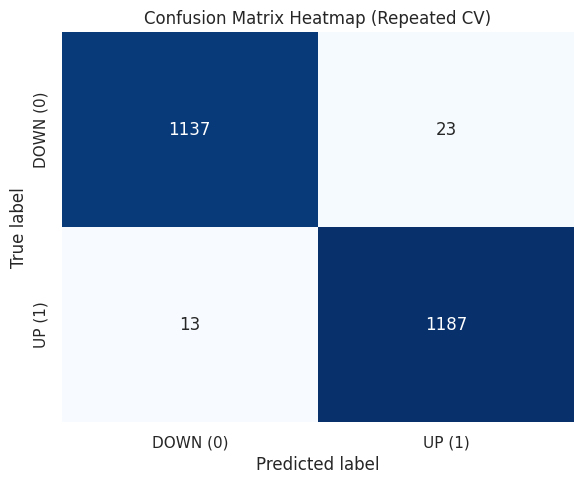

Rows with labels available: 118
CV setup: 5-fold x 20 repeats = 100 model fits
Total test-case evaluations: 2360
Average evaluations per row: 20.0

Classification report (aggregated across all CV test folds):
              precision    recall  f1-score   support

        DOWN      0.989     0.980     0.984      1160
          UP      0.981     0.989     0.985      1200

    accuracy                          0.985      2360
   macro avg      0.985     0.985     0.985      2360
weighted avg      0.985     0.985     0.985      2360



In [17]:
# Step 7.1: Simple confusion matrix heatmap on the model-ready CSV 
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RepeatedStratifiedKFold

# Load the model-ready dataset created in Step 7.
project_root = Path("..")
model_ready_path = project_root / "data" / "processed" / "nvda_multimodal_final_model_ready.csv"

if not model_ready_path.exists():
    raise FileNotFoundError(
        f"Missing model-ready file: {model_ready_path}. Run Step 7 first."
    )

model_df = pd.read_csv(model_ready_path)
target_col = "pm_direction_up"

if target_col not in model_df.columns:
    raise ValueError(f"Missing target column: {target_col}")

# Use a simple numeric feature set: drop date and target from the input matrix.
feature_cols = [c for c in model_df.columns if c not in ["trade_date", target_col]]
X = model_df[feature_cols].copy()
y = pd.to_numeric(model_df[target_col], errors="coerce")

# Convert features to numeric and fill remaining missing values with column medians.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
X = X.fillna(X.median(numeric_only=True))

# Keep only rows where target is available.
valid_mask = y.notna()
X = X.loc[valid_mask].copy()
y = y.loc[valid_mask].astype(int)

if y.nunique() < 2:
    raise ValueError("Confusion matrix requires at least two target classes.")

# Repeated CV gives many more test evaluations than one 80/20 split.
N_SPLITS = 5
N_REPEATS = 20
cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=42,
 )

base_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced",
 )

all_true = []
all_pred = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = clone(base_model)
    model.fit(X_train, y_train)
    fold_pred = model.predict(X_test)

    all_true.extend(y_test.tolist())
    all_pred.extend(fold_pred.tolist())

# Build confusion matrix and display it as a heatmap.
cm = confusion_matrix(all_true, all_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["DOWN (0)", "UP (1)"],
    yticklabels=["DOWN (0)", "UP (1)"],
 )
plt.title("Confusion Matrix Heatmap (Repeated CV)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

total_evals = len(all_true)
print(f"Rows with labels available: {len(y)}")
print(f"CV setup: {N_SPLITS}-fold x {N_REPEATS} repeats = {N_SPLITS * N_REPEATS} model fits")
print(f"Total test-case evaluations: {total_evals}")
print(f"Average evaluations per row: {total_evals / len(y):.1f}")

print("\nClassification report (aggregated across all CV test folds):")
print(classification_report(all_true, all_pred, labels=[0, 1], target_names=["DOWN", "UP"], digits=3))

### <span style="color:#6D28D9;">Findings: Final CSV EDA and Pruning Decisions</span>

This step creates a model-ready training dataset from the full multimodal final CSV using a transparent, EDA-driven process.

- Target used for pruning decisions: `pm_direction_up`.
- Correlation rule used: drop one feature from pairs where $|corr| > 0.90$.
- Output choice: keep the original final CSV unchanged and save a new file `data/processed/nvda_multimodal_final_model_ready.csv`.
- Categorical choice: drop `event_query`, `matched_event`, and `dominant_source` for a numeric-first training table.

Rows and columns after pruning:
- Original rows: 570
- Model-ready rows (with target available): 118
- Model-ready columns: 19

Dropped columns and why:
- `event_query`, `matched_event`, `dominant_source`: dropped as categorical text (not encoded in this simple training table).
- `headline_count_y`: dropped because `headline_count_x` had lower missingness.
- `high` and `low`: dropped due to very high correlation with `start_price`.
- `unique_source_count`: dropped due to high correlation with `headline_count_x`.
- `positive_share`, `neutral_share`, `negative_share`: dropped due to high correlation with their probability means.
- `pre_market_volume_relative`, `has_polymarket_label`: dropped because they became constant after filtering to labeled rows.


### <span style="color:#7D28D9;">Final CSV Feature Summary and Limitations</span>

For training, the notebook now uses the pruned model-ready file `data/processed/nvda_multimodal_final_model_ready.csv` (derived from the full final CSV).

#### Feature dictionary (model-ready CSV)
- `trade_date`: date of trade.
- `start_price`: stock price at market open.
- `end_price`: stock price at market close.
- `volume`: total number of shares traded that day.
- `pre_market_gap_pct`: percent gap between premarket context and regular session open.
- `gap_direction_matches_trend`: binary stock signal showing whether opening gap direction matched the day trend.
- `open_price`: first Polymarket YES price observed for that trade date.
- `close_price`: last Polymarket YES price observed for that trade date.
- `pm_return`: Polymarket return for the day computed from open_price and close_price.
- `headline_count_x`: daily headline count from the news summary merge.
- `avg_headline_length`: average headline length for that date.
- `median_headline_length`: median headline length for that date.
- `max_headline_length`: maximum headline length for that date.
- `positive_prob_mean`: mean FinBERT positive probability for that date.
- `neutral_prob_mean`: mean FinBERT neutral probability for that date.
- `negative_prob_mean`: mean FinBERT negative probability for that date.
- `finbert_score_mean`: mean daily sentiment score (positive minus negative probability).
- `finbert_score_std`: standard deviation of daily FinBERT sentiment score.
- `pm_direction_up`: target label for training (1 when Polymarket closes above open, else 0).

#### Important limitation
- Filtering to labeled rows reduced coverage from 570 rows to 118 rows.
- Some sentiment features remain missing on dates without headlines and may require imputation or missingness flags in later modeling.
- The current model-ready file is numeric-first; dropped categorical text may still carry useful signal if encoded in future iterations.

#### What could be improved later
- Add a `has_sentiment` indicator before training to make missing sentiment explicit.
- Compare this numeric-first baseline with encoded text/categorical variants.
- Use time-based validation splits to reduce leakage risk and improve realistic evaluation.
- Add lag and rolling-window features for stock, Polymarket, and sentiment signals.

## <span style="color:#0F766E;">D.BONUS :) Polymarket Master Dataset Features Survivor Guide</span>

In this section, I explain where each Polymarket master feature comes from.
</div>

### <span style="color:#1D4ED8;">1) Data Flow </span>
1. I collect intraday Polymarket YES/NO prices for NVDA-related daily markets.
2. I add time and momentum features from the intraday YES price stream.
3. I build 60-minute forward labels to measure what happened next.
4. I merge stock context features by `trade_date`.
5. I save everything to `data/processed/polymarket_master_dataset_h60m.csv`.

### <span style="color:#2563EB;">2) Core Market Columns</span>
| Feature | How it is derived |
|---|---|
| `trade_date` | Date extracted from Polymarket timestamp |
| `timestamp_et` | Raw timestamp from Polymarket stream |
| `up_price` | Raw Polymarket YES price |
| `down_price` | Raw NO price from feed (often close to `1 - up_price`) |

### <span style="color:#7C3AED;">3) Time Position Features</span>
| Feature | How it is derived |
|---|---|
| `minute_from_open` | Difference between `timestamp_et` and open time |
| `minute_sin` | `sin(2*pi*minute_from_open/session_length)` |
| `minute_cos` | `cos(2*pi*minute_from_open/session_length)` |

### <span style="color:#0D9488;">4) Intraday Momentum Features (from YES price)</span>
| Feature | How it is derived |
|---|---|
| `up_ret_1` | 1-step return of `up_price` |
| `up_ret_3` | 3-step return of `up_price` |
| `up_sma_5` | 5-step moving average of `up_price` |
| `up_std_5` | 5-step rolling standard deviation of `up_price` |
| `up_vs_sma_5` | `up_price - up_sma_5` |

### <span style="color:#B45309;">5) Stock Context Features (joined by date)</span>
| Feature | How it is derived |
|---|---|
| `pre_market_gap_pct` | Percent gap between pre-market context and regular open |
| `pre_market_volume_relative` | Pre-market volume vs recent baseline |
| `gap_direction_matches_trend` | 1 if gap direction matches day trend, else 0 |
| `stock_return_1d` | `(end_price - start_price) / start_price` |
| `high_low_range_pct` | `(high - low) / start_price` (or equivalent range ratio) |
| `volume_vs_5d` | `volume / rolling_5d_avg_volume` |

### <span style="color:#DC2626;">6) 60-Minute Forward Outcome Features</span>
| Feature | How it is derived |
|---|---|
| `future_return_h60m` | Forward return from current `up_price` to +60 minutes |
| `target_up_move_h60m` | 1 if `future_return_h60m > 0`, else 0 |
| `is_underpriced_up_h60m` | 1 when current UP price looked too low vs realized 60-min move |
| `is_overpriced_up_h60m` | 1 when current UP price looked too high vs realized 60-min move |
| `realized_edge_h60m` | Realized move minus what current pricing implied |

### <span style="color:#92400E;">7) Event Metadata</span>
| Feature | How it is derived |
|---|---|
| `event_query` | Built by extractor from NVDA daily event naming |
| `matched_event` | Returned by market matching logic |

### <span style="color:#15803D;">8) Daily Stock Backbone Features</span>
| Feature | How it is derived |
|---|---|
| `start_price` | From daily stock data |
| `end_price` | From daily stock data |
| `high` | From daily stock data |
| `low` | From daily stock data |
| `volume` | From daily stock data |
| `stock_return_lag1` | 1-day lag of daily return |
| `stock_return_lag2` | 2-day lag of daily return |
| `ret_mean_5d` | Rolling 5-day mean of daily returns |
| `ret_std_5d` | Rolling 5-day std of daily returns |
| `log_volume` | `log(1 + volume)` |
| `close_pos_in_range` | `(end_price - low) / (high - low)` |

### <span style="color:#4F46E5;">9) Direction and Return Labels Used in Notebook</span>
| Feature | How it is derived |
|---|---|
| `pm_direction_up` | 1 if Polymarket ends higher than it starts for the period, else 0 |
| `pm_return` | `(close_price - open_price) / open_price` (or equivalent start/end move) |

### <span style="color:#0F766E;">Simple Takeaway</span>
- The master file keeps both intraday market behavior and daily stock context in one place.
- Short-horizon label columns (`future_return_h60m`, `target_up_move_h60m`) are used to learn what happens next.
- Daily direction/return columns (`pm_direction_up`, `pm_return`) are useful for diagnostics, but can be very target-linked in model training.